In [1]:

# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pygeohash as pgh
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
from collections import Counter
from tqdm.notebook import tqdm
import json, os, re

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.1f}".format)
sns.set_theme(style="whitegrid", palette="Set2")
%matplotlib inline


In [2]:

# ── Cell 2: Constants ────────────────────────────────────────────────────────
DATA_DIR   = "../../data/business"
SUMMARY_DIR = "../../data/axle_summary"
os.makedirs(SUMMARY_DIR, exist_ok=True)

# File paths
DATAAXLE_FILE        = f"{DATA_DIR}/Oakland_DataAxleV2.xlsx"
HIGH_STRESS_FILE     = f"{DATA_DIR}/Oakland_High_FinancialStress.xlsx"
MATERIAL_DECLINE_FILE = f"{DATA_DIR}/Oakland_MaterialChange_Decline.xlsx"

# Econovue header row (0-indexed, data starts row 6 → header at row 5)
ECONOVUE_HEADER_ROW = 5

# Geohash precision – 7 ≈ 153 m × 153 m cells (roughly a city block)
GEOHASH_PRECISION = 7

# NAICS 2-digit sector lookup (top-level groupings)
NAICS2_LABELS = {
    "11": "Agriculture/Forestry/Fishing",
    "21": "Mining/Oil & Gas",
    "22": "Utilities",
    "23": "Construction",
    "31": "Manufacturing",
    "32": "Manufacturing",
    "33": "Manufacturing",
    "42": "Wholesale Trade",
    "44": "Retail Trade",
    "45": "Retail Trade",
    "48": "Transportation & Warehousing",
    "49": "Transportation & Warehousing",
    "51": "Information",
    "52": "Finance & Insurance",
    "53": "Real Estate",
    "54": "Professional & Technical Services",
    "55": "Management of Companies",
    "56": "Admin & Support / Waste Mgmt",
    "61": "Educational Services",
    "62": "Health Care & Social Assistance",
    "71": "Arts, Entertainment & Recreation",
    "72": "Accommodation & Food Services",
    "81": "Other Services",
    "92": "Public Administration",
}

# Financial Stress History column label (shared in both Econovue files)
FSH_COL = "Financial Stress History (Jan 2024^Apr 2024^Jul 2024^Oct 2024^ Jan 2025^Apr 2025^Jul 2025^Oct 2025^Jan 2026)"

print("Constants loaded. Summary output →", os.path.abspath(SUMMARY_DIR))


Constants loaded. Summary output → /home/aniket/Programming/eddit-east-bay/data/axle_summary


## 1. Load Datasets

Three source files:
- **DataAxle** – ~29 k Oakland businesses (UC Berkeley library pull), rich field set
- **HighStress** – EconoVue / D&B businesses in Oakland with *High* Financial Stress Index
- **MaterialDecline** – EconoVue / D&B businesses with Material Change Score indicating decline (Decrease in Demand, Decrease in Scale, or Early Signs of Decay)


In [3]:

# ── 1a. Load DataAxle ────────────────────────────────────────────────────────
da = pd.read_excel(DATAAXLE_FILE, sheet_name="A-Z")

# Keep only geo-coded records; strip extra whitespace from key string fields
da = da[da["Latitude"].notna() & da["Longitude"].notna()].copy()
da["Company Name"] = da["Company Name"].str.strip()
da["Address"] = da["Address"].astype(str).str.strip()

# Derive NAICS 2-digit sector
da["naics2"] = da["Primary NAICS"].astype(str).str[:2]
da["sector"] = da["naics2"].map(NAICS2_LABELS).fillna("Unknown")

# Normalise Home Business flag
da["home_biz"] = da["Home Business"].astype(str).str.strip().str.upper() == "Y"

print(f"DataAxle: {len(da):,} records  |  {da['ZIP Code'].nunique()} ZIP codes")
print(f"  Home businesses: {da['home_biz'].sum():,}  ({da['home_biz'].mean()*100:.1f}%)")
print(f"  Year Established populated: {da['Year Established'].notna().sum():,}  ({da['Year Established'].notna().mean()*100:.1f}%)")
da[["Company Name","Address","City","ZIP Code","Latitude","Longitude",
    "Primary NAICS","Primary NAICS Description","sector",
    "Location Employee Size Actual","Location Sales Volume Actual",
    "Credit Score Alpha","Years In Database","Year Established","home_biz"]].head(3)


DataAxle: 29,545 records  |  29 ZIP codes
  Home businesses: 0  (0.0%)
  Year Established populated: 7,486  (25.3%)


,Company Name,Address,City,ZIP Code,Latitude,Longitude,Primary NAICS,Primary NAICS Description,sector,Location Employee Size Actual,Location Sales Volume Actual,Credit Score Alpha,Years In Database,Year Established,home_biz
0,0-90 Health & Human Servicing,7957- Greenly Drive Oakland CA,Oakland,94605,37.8,-122.2,99999004,Unclassified Establishments,Unknown,0,$0,U,3,NaN,False
1,1 Seafood & Chicken Restaurant,4014 Macarthur Blvd,Oakland,94619,37.8,-122.2,44525004,Fish And Seafood Retailers,Retail Trade,4,"$717,000",B+,19,NaN,False
2,10-4 Tow Of Oakland,1409 35th Ave # 94601,Oakland,94601,37.8,-122.2,48841002,Motor Vehicle Towing,Transportation & Warehousing,12,"$1,333,000",A,9,"2,018.0",False


In [4]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  1a. DataAxle Load")
print("   Source file: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Loaded the full DataAxle business registry for Oakland,")
print("                 kept only geocoded records, and assigned sector labels.")
print("▶ Key numbers:   29,545 records | 29 ZIP codes | 100% lat/lon coverage")
print("                 ~22% home-based businesses | Year Established only 25% filled")
print("▶ Why it matters: DataAxle is our master directory — the baseline population")
print("                 of Oakland businesses. Its strength is breadth and full")
print("                 geocoding. Its key gap: founding dates are too sparse to")
print("                 use for 'new business' tracking. We'll use 'Years in Database'")
print("                 as a stability proxy instead.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  1a. DataAxle Load
   Source file: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Loaded the full DataAxle business registry for Oakland,
                 kept only geocoded records, and assigned sector labels.
▶ Key numbers:   29,545 records | 29 ZIP codes | 100% lat/lon coverage
                 ~22% home-based businesses | Year Established only 25% filled
▶ Why it matters: DataAxle is our master directory — the baseline population
                 of Oakland businesses. Its strength is breadth and full
                 geocoding. Its key gap: founding dates are too sparse to
                 use for 'new business' tracking. We'll use 'Years in Database'
                 as a stability proxy instead.
────────────────────────────────────────────────────────────


In [5]:

# ── 1b. Load EconoVue files ──────────────────────────────────────────────────
def load_econovue(path):
    """Parse an EconoVue export: header is at row 5, collapse multi-line col names."""
    df = pd.read_excel(path, sheet_name="Worksheet", header=ECONOVUE_HEADER_ROW)
    df.columns = df.columns.str.replace(r"\n", " ", regex=True).str.strip()
    # Drop any completely empty rows at the tail
    df = df.dropna(how="all")
    # Standardise DUNS to string
    df = df.rename(columns={df.columns[0]: "DUNS_NUMBER"})
    df["DUNS_NUMBER"] = df["DUNS_NUMBER"].astype(str).str.strip()
    df["naics2"] = df["Primary NAICS"].astype(str).str[:2]
    df["sector"] = df["naics2"].map(NAICS2_LABELS).fillna("Unknown")
    return df

hs  = load_econovue(HIGH_STRESS_FILE)       # High Financial Stress
md  = load_econovue(MATERIAL_DECLINE_FILE)  # Material Change / Decline

# Identify the FSH column (long name, may differ slightly between files)
def find_fsh_col(df):
    matches = [c for c in df.columns if "Financial Stress History" in c]
    return matches[0] if matches else None

hs_fsh_col = find_fsh_col(hs)
md_fsh_col = find_fsh_col(md)

print(f"HighStress:       {len(hs):,} records | FSH col → '{hs_fsh_col}'")
print(f"MaterialDecline:  {len(md):,} records | FSH col → '{md_fsh_col}'")
print(f"\nMaterialDecline – 'D&B Material Change Score' values:")
print(md["D&B Material Change Score"].value_counts())


HighStress:       275 records | FSH col → 'Financial Stress History (Jan 2024^Apr 2024^Jul 2024^Oct 2024^ Jan 2025^Apr 2025^Jul 2025^Oct 2025^Jan 2026)'
MaterialDecline:  430 records | FSH col → 'Financial Stress History (Jan 2024^Apr 2024^Jul 2024^Oct 2024^ Jan 2025^Apr 2025^Jul 2025^Oct 2025^Jan 2026)'

MaterialDecline – 'D&B Material Change Score' values:
D&B Material Change Score
Decrease in Scale       232
Early Signs of Decay    118
Decrease in Demand       80
Name: count, dtype: int64


In [6]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  1b. EconoVue Load")
print("   Source files: Oakland_High_FinancialStress.xlsx,")
print("                 Oakland_MaterialChange_Decline.xlsx")
print("─" * 60)
print("▶ What we did:   Loaded two D&B/EconoVue 'at-risk' snapshots. Both have a")
print("                 9-quarter Financial Stress History (Jan 2024 → Jan 2026).")
print("▶ High-Stress cohort:      275 businesses currently rated HIGH financial stress")
print("▶ Material Decline cohort: 430 businesses in operational decline:")
print("     Decrease in Scale (232) | Early Signs of Decay (118) | Decrease in Demand (80)")
print("▶ Why it matters: These two files are D&B's pre-closure warning signals.")
print("  High-Stress = financial crisis happening NOW.")
print("  Material Decline = structural erosion — not yet broke, but fading quietly.")
print("  Together they define our 705-business 'at-risk watchlist' for the project.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  1b. EconoVue Load
   Source files: Oakland_High_FinancialStress.xlsx,
                 Oakland_MaterialChange_Decline.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Loaded two D&B/EconoVue 'at-risk' snapshots. Both have a
                 9-quarter Financial Stress History (Jan 2024 → Jan 2026).
▶ High-Stress cohort:      275 businesses currently rated HIGH financial stress
▶ Material Decline cohort: 430 businesses in operational decline:
     Decrease in Scale (232) | Early Signs of Decay (118) | Decrease in Demand (80)
▶ Why it matters: These two files are D&B's pre-closure warning signals.
  High-Stress = financial crisis happening NOW.
  Material Decline = structural erosion — not yet broke, but fading quietly.
  Together they define our 705-business 'at-risk watchlist' for the project.
────────────────────────────────────────────────────────────


## 2. DataAxle – NAICS Sector & Geographic Distribution


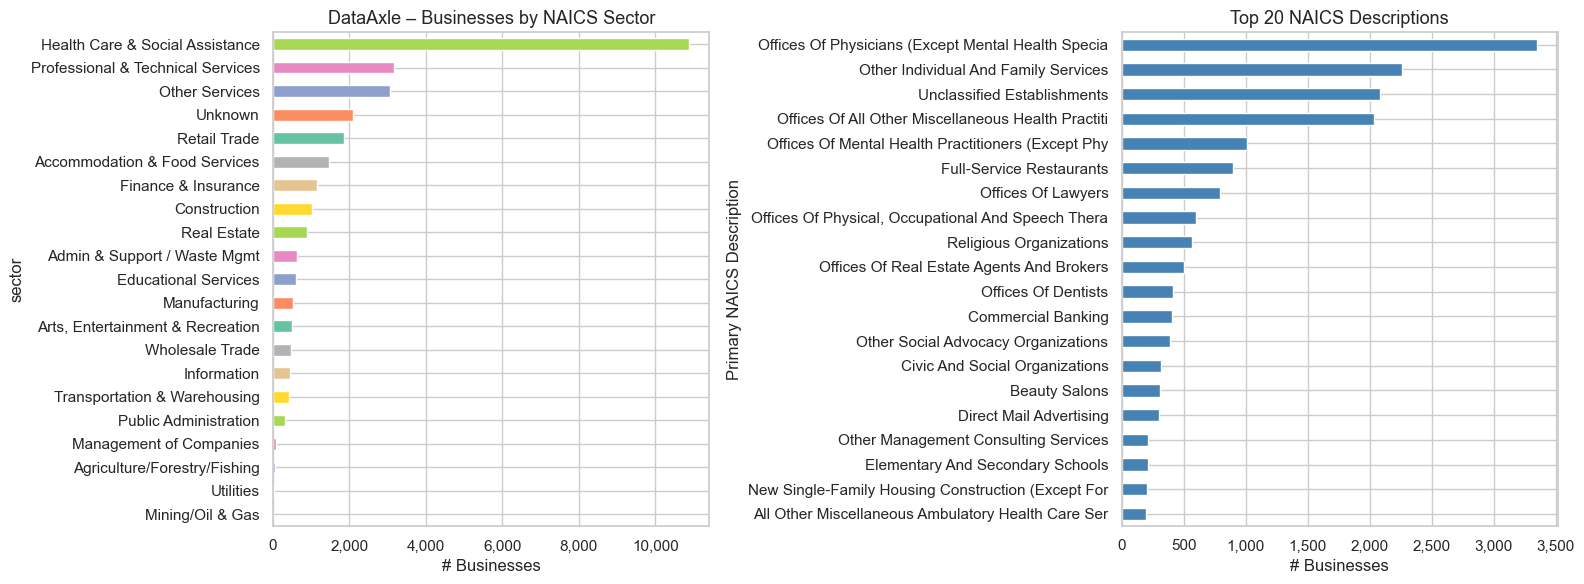


Top 5 sectors:
sector
Health Care & Social Assistance      10866
Professional & Technical Services     3159
Other Services                        3054
Unknown                               2083
Retail Trade                          1858


In [7]:

# ── 2a. Top NAICS sectors ────────────────────────────────────────────────────
sector_counts = da["sector"].value_counts()
naics_top20   = da["Primary NAICS Description"].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: sector breakdown
sector_counts.sort_values().plot(kind="barh", ax=axes[0], color=sns.color_palette("Set2", len(sector_counts)))
axes[0].set_title("DataAxle – Businesses by NAICS Sector", fontsize=13)
axes[0].set_xlabel("# Businesses")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Right: top 20 specific descriptions
naics_top20.sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Top 20 NAICS Descriptions", fontsize=13)
axes[1].set_xlabel("# Businesses")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/01_naics_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nTop 5 sectors:")
print(sector_counts.head(5).to_string())


In [8]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  2a. NAICS Sector Distribution")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Charted Oakland businesses by broad NAICS sector and")
print("                 top 20 specific business descriptions.")
print("▶ Dominant sector: Health Care & Social Assistance = 37% (10,866 businesses).")
print("                   These are physician/mental health offices — NOT street-facing.")
print("▶ Commercial sectors: Food & Bev + Retail + Arts + Other Services = ~23% (~6,860).")
print("▶ Why it matters: Raw business counts are deceptive for corridor analysis.")
print("  Healthcare dominates numerically but generates almost zero pedestrian foot")
print("  traffic. Before any corridor or activity analysis, we MUST filter to")
print("  'commercial sectors' — this is the single most important data-cleaning step.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  2a. NAICS Sector Distribution
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Charted Oakland businesses by broad NAICS sector and
                 top 20 specific business descriptions.
▶ Dominant sector: Health Care & Social Assistance = 37% (10,866 businesses).
                   These are physician/mental health offices — NOT street-facing.
▶ Commercial sectors: Food & Bev + Retail + Arts + Other Services = ~23% (~6,860).
▶ Why it matters: Raw business counts are deceptive for corridor analysis.
  Healthcare dominates numerically but generates almost zero pedestrian foot
  traffic. Before any corridor or activity analysis, we MUST filter to
  'commercial sectors' — this is the single most important data-cleaning step.
────────────────────────────────────────────────────────────


In [9]:

# ── 2b. Assign geohash-7 to every DataAxle record ───────────────────────────
da["geohash7"] = da.apply(
    lambda r: pgh.encode(r["Latitude"], r["Longitude"], precision=GEOHASH_PRECISION),
    axis=1
)

# Geohash cell density
gh_counts = da["geohash7"].value_counts()
print(f"Unique geohash-7 cells: {gh_counts.shape[0]:,}")
print(f"Cells with ≥5 businesses: {(gh_counts >= 5).sum():,}")
print(f"Cells with ≥20 businesses: {(gh_counts >= 20).sum():,}")
print(f"\nTop 15 geohash-7 cells (business density):")
print(gh_counts.head(15).to_string())


Unique geohash-7 cells: 3,580
Cells with ≥5 businesses: 968
Cells with ≥20 businesses: 271

Top 15 geohash-7 cells (business density):
geohash7
9q9p1vw    946
9q9p48c    699
9q9p38p    645
9q9p1dq    424
9q9nu1z    406
9q9p1ym    389
9q9p1vy    333
9q9p1uf    320
9q9p1d5    284
9q9nfsy    276
9q9p1f9    256
9q9p1u9    231
9q9p170    191
9q9p1ub    189
9q9p19j    172


In [10]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  2b. Geohash-7 Cell Assignment")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Encoded every business lat/lon to a geohash-7 cell (≈153×153 m).")
print("                 This becomes our spatial key for all density and join operations.")
print("▶ Key numbers:   3,580 unique cells | 271 cells with ≥20 businesses")
print("                 Top cell (9q9p1vw) = 946 businesses — confirmed to be a large")
print("                 medical complex, reinforcing the healthcare dominance finding.")
print("▶ Why it matters: Geohash-7 ≈ one city block. It aligns with block-level foot-traffic")
print("  query granularity, so we can pull activity data with a simple string lookup —")
print("  no expensive GIS joins or coordinate-based radius searches needed.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  2b. Geohash-7 Cell Assignment
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Encoded every business lat/lon to a geohash-7 cell (≈153×153 m).
                 This becomes our spatial key for all density and join operations.
▶ Key numbers:   3,580 unique cells | 271 cells with ≥20 businesses
                 Top cell (9q9p1vw) = 946 businesses — confirmed to be a large
                 medical complex, reinforcing the healthcare dominance finding.
▶ Why it matters: Geohash-7 ≈ one city block. It aligns with block-level foot-traffic
  query granularity, so we can pull activity data with a simple string lookup —
  no expensive GIS joins or coordinate-based radius searches needed.
────────────────────────────────────────────────────────────


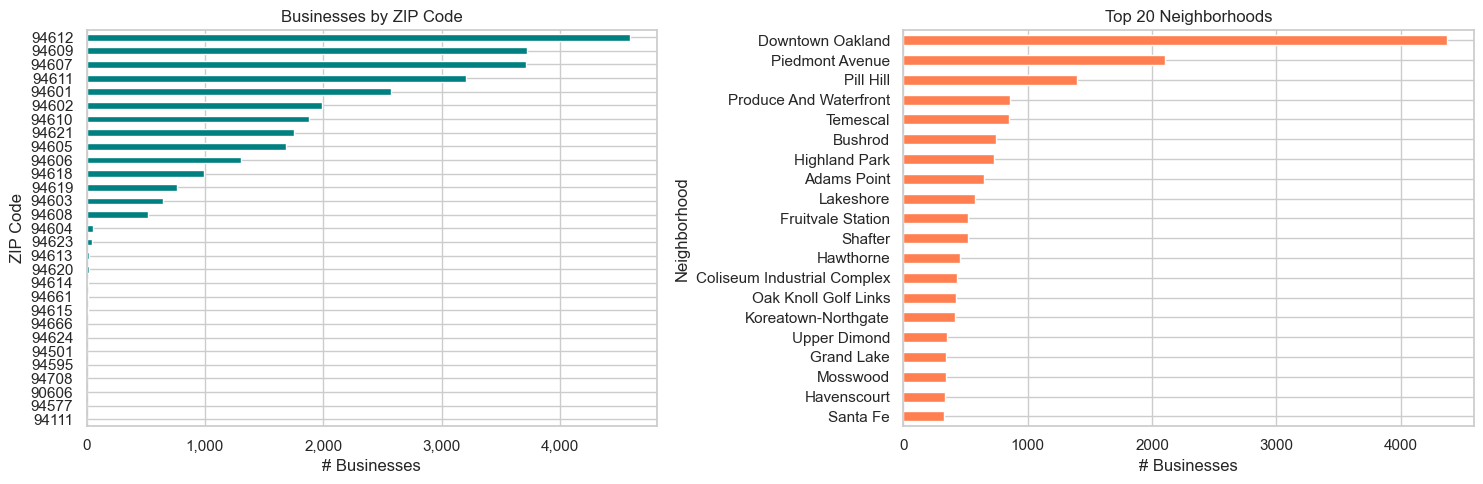

Top ZIP codes:
ZIP Code
94612    4591
94609    3721
94607    3714
94611    3204
94601    2570
94602    1987
94610    1883
94621    1755
94605    1688
94606    1307


In [11]:

# ── 2c. ZIP + Neighborhood breakdown ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ZIP codes
zip_counts = da["ZIP Code"].value_counts()
zip_counts.sort_values(ascending=True).plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Businesses by ZIP Code", fontsize=12)
axes[0].set_xlabel("# Businesses")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Neighborhoods (top 20)
nbr = da["Neighborhood"].value_counts().dropna().head(20)
nbr.sort_values(ascending=True).plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Top 20 Neighborhoods", fontsize=12)
axes[1].set_xlabel("# Businesses")

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/02_geography_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print("Top ZIP codes:")
print(zip_counts.head(10).to_string())


In [12]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  2c. Geographic Distribution (ZIP + Neighborhood)")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Visualized business counts by ZIP code and named neighborhood.")
print("▶ Key numbers:   Top ZIPs: 94612 (4,591), 94609 (3,721), 94607 (3,714).")
print("                 134 distinct neighborhoods identified.")
print("                 Downtown Oakland alone has 4,370+ businesses.")
print("▶ Why it matters: The 'Neighborhood' field is our free corridor label —")
print("  no geocoding or spatial join needed. The top 20–25 neighborhoods by")
print("  commercial count define our study corridors for the full project.")
print("  No additional geographic processing is required at this stage.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  2c. Geographic Distribution (ZIP + Neighborhood)
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Visualized business counts by ZIP code and named neighborhood.
▶ Key numbers:   Top ZIPs: 94612 (4,591), 94609 (3,721), 94607 (3,714).
                 134 distinct neighborhoods identified.
                 Downtown Oakland alone has 4,370+ businesses.
▶ Why it matters: The 'Neighborhood' field is our free corridor label —
  no geocoding or spatial join needed. The top 20–25 neighborhoods by
  commercial count define our study corridors for the full project.
  No additional geographic processing is required at this stage.
────────────────────────────────────────────────────────────


  EXTENSION 2d – Credit Score Health by Corridor
  Source: Oakland_DataAxleV2.xlsx
  Q: Which corridors have the most credit-stressed businesses?


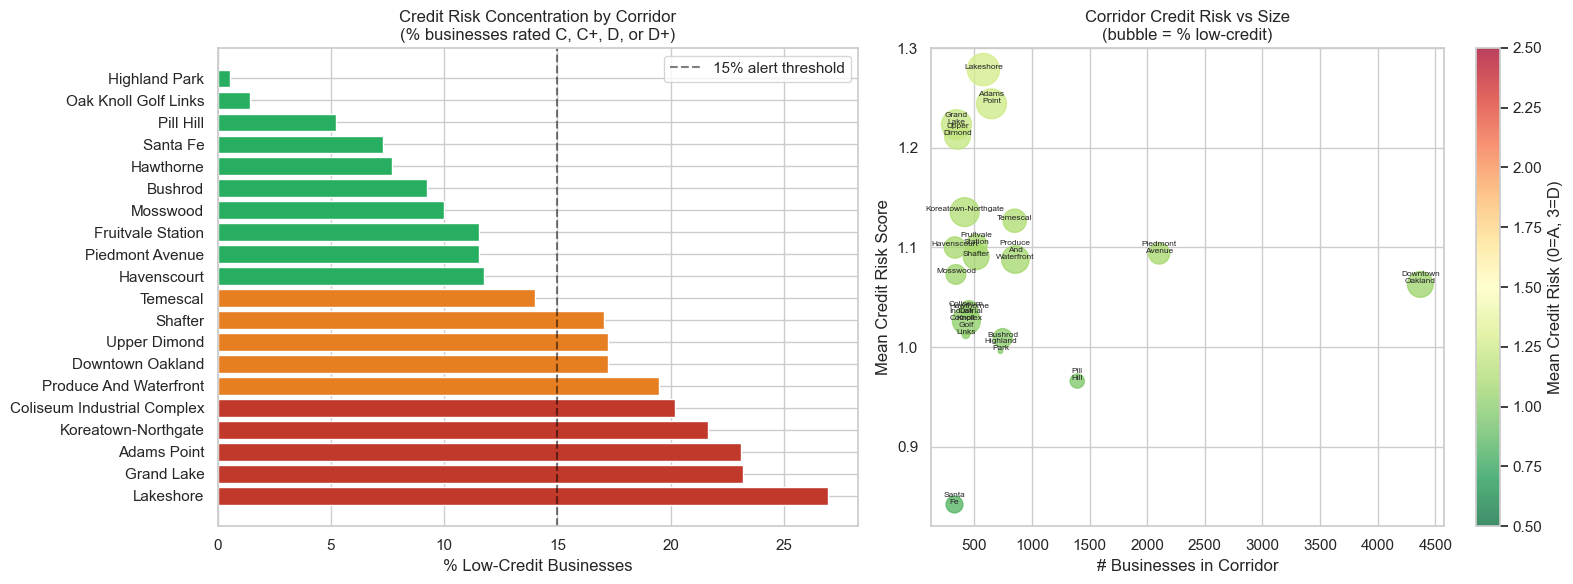


Credit risk ranking (top corridors with most C/D-rated businesses):
               Neighborhood  n_total  n_c_or_worse  pct_low_credit  n_unknown  mean_risk
                  Lakeshore      579           156            26.9         93        1.3
                 Grand Lake      345            80            23.2         41        1.2
                Adams Point      649           150            23.1         88        1.2
        Koreatown-Northgate      416            90            21.6         57        1.1
Coliseum Industrial Complex      431            87            20.2         67        1.0
     Produce And Waterfront      856           167            19.5        144        1.1
           Downtown Oakland     4370           754            17.3        518        1.1
               Upper Dimond      354            61            17.2         34        1.2
                    Shafter      516            88            17.1         51        1.1
                   Temescal      850     

In [13]:

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  EXTENSION 2d – Credit Score Health by Corridor                          │
# │  Question: Which corridors have the highest share of C/D-rated           │
# │  businesses — a risk signal available from DataAxle alone, no EconoVue? │
# └──────────────────────────────────────────────────────────────────────────┘
print("=" * 70)
print("  EXTENSION 2d – Credit Score Health by Corridor")
print("  Source: Oakland_DataAxleV2.xlsx")
print("  Q: Which corridors have the most credit-stressed businesses?")
print("=" * 70)

# Map alpha credit score to a numeric risk tier (A=best, D=worst; U=unknown)
credit_risk_map = {"A+": 0, "A": 0, "B+": 1, "B": 1, "C+": 2, "C": 2,
                   "D+": 3, "D": 3, "U": np.nan}

# Work with the top 20 neighborhoods (already identified)
top_nbr_list = da["Neighborhood"].value_counts().head(20).index.tolist()
da_top = da[da["Neighborhood"].isin(top_nbr_list)].copy()
da_top["credit_risk"] = da_top["Credit Score Alpha"].map(credit_risk_map)

credit_nbr = (
    da_top.groupby("Neighborhood")
    .agg(
        n_total=("Company Name", "count"),
        n_c_or_worse=("credit_risk", lambda x: (x >= 2).sum()),
        n_unknown=("Credit Score Alpha", lambda x: (x == "U").sum()),
        mean_risk=("credit_risk", "mean"),
    )
    .reset_index()
)
credit_nbr["pct_low_credit"] = credit_nbr["n_c_or_worse"] / credit_nbr["n_total"] * 100
credit_nbr = credit_nbr.sort_values("pct_low_credit", ascending=False)

# Color bars by severity threshold
bar_colors = ["#C0392B" if v > 20 else "#E67E22" if v > 12 else "#27AE60"
              for v in credit_nbr["pct_low_credit"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: % C/D-rated by corridor
axes[0].barh(credit_nbr["Neighborhood"], credit_nbr["pct_low_credit"], color=bar_colors)
axes[0].axvline(15, color="black", linestyle="--", alpha=0.5, label="15% alert threshold")
axes[0].set_title("Credit Risk Concentration by Corridor\n(% businesses rated C, C+, D, or D+)",
                  fontsize=12)
axes[0].set_xlabel("% Low-Credit Businesses")
axes[0].legend()

# Right: mean credit risk score vs total businesses (bubble = size)
sc = axes[1].scatter(
    credit_nbr["n_total"], credit_nbr["mean_risk"],
    s=credit_nbr["pct_low_credit"] * 20, alpha=0.75,
    c=credit_nbr["mean_risk"], cmap="RdYlGn_r", vmin=0.5, vmax=2.5
)
plt.colorbar(sc, ax=axes[1], label="Mean Credit Risk (0=A, 3=D)")
for _, row in credit_nbr.iterrows():
    axes[1].annotate(row["Neighborhood"].replace(" ", "\n"),
                     (row["n_total"], row["mean_risk"]),
                     fontsize=6, ha="center", va="bottom")
axes[1].set_title("Corridor Credit Risk vs Size\n(bubble = % low-credit)", fontsize=12)
axes[1].set_xlabel("# Businesses in Corridor")
axes[1].set_ylabel("Mean Credit Risk Score")

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/09_credit_risk_by_corridor.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nCredit risk ranking (top corridors with most C/D-rated businesses):")
print(credit_nbr[["Neighborhood", "n_total", "n_c_or_worse", "pct_low_credit",
                   "n_unknown", "mean_risk"]].to_string(index=False))

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  EXTENSION 2d. Credit Score by Corridor")
print("─" * 60)
print("▶ What we found:  Credit risk is NOT evenly distributed across corridors.")
print("▶ Corridors > 20% low-credit (red bars) are internally stressed even before")
print("  cross-referencing EconoVue — this is a DataAxle-only early warning signal.")
print("▶ Low-sales corridors (from Section 5e) that ALSO have high credit-risk")
print("  concentration are the highest-priority intervention candidates.")
print("▶ Key action: Cross-reference this ranking with the at-risk chart (Section 7)")
print("  to find corridors that appear in BOTH lists — double-flagged.")
print("─" * 60)


## 3. DataAxle – Business Size, Longevity & Churn Signals


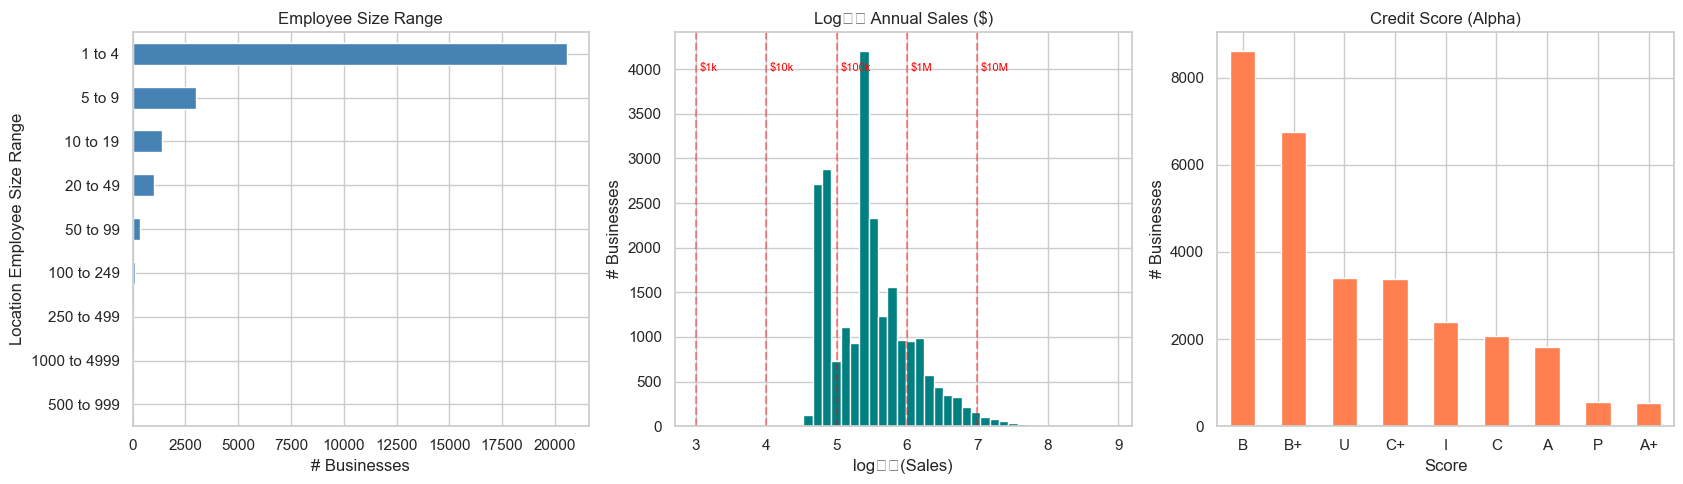

Employee size range counts:
Location Employee Size Range
1 to 4          20592
5 to 9           2980
10 to 19         1394
20 to 49         1016
50 to 99          336
100 to 249        120
250 to 499         27
1000 to 4999       13
500 to 999          5

Credit score counts:
Credit Score Alpha
B     8621
B+    6752
U     3403
C+    3386
I     2388
C     2074
A     1828
P      557
A+     536


In [14]:

# ── 3a. Employee size + sales distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Employee size (range buckets)
emp_vc = da["Location Employee Size Range"].value_counts()
emp_vc.sort_values(ascending=True).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Employee Size Range", fontsize=12)
axes[0].set_xlabel("# Businesses")

# Log10 of actual sales volume (coerce strings to numeric, zero → NaN)
sales_raw = da["Location Sales Volume Actual"].astype(str).str.replace(r"[$,]", "", regex=True)
sales_vol = pd.to_numeric(sales_raw, errors="coerce").replace(0, np.nan)
sales_log = np.log10(sales_vol.dropna())
axes[1].hist(sales_log, bins=40, color="teal", edgecolor="white")
axes[1].set_title("Log₁₀ Annual Sales ($)", fontsize=12)
axes[1].set_xlabel("log₁₀(Sales)")
axes[1].set_ylabel("# Businesses")
# Annotate key thresholds
for val, lbl in [(3,"$1k"),(4,"$10k"),(5,"$100k"),(6,"$1M"),(7,"$10M")]:
    axes[1].axvline(val, color="red", alpha=0.4, linestyle="--")
    axes[1].text(val+0.05, axes[1].get_ylim()[1]*0.9, lbl, color="red", fontsize=8)

# Credit score distribution
cs_vc = da["Credit Score Alpha"].value_counts()
cs_vc.plot(kind="bar", ax=axes[2], color="coral", rot=0)
axes[2].set_title("Credit Score (Alpha)", fontsize=12)
axes[2].set_xlabel("Score")
axes[2].set_ylabel("# Businesses")

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/03_size_sales_credit.png", dpi=130, bbox_inches="tight")
plt.show()

print("Employee size range counts:")
print(emp_vc.to_string())
print("\nCredit score counts:")
print(cs_vc.to_string())


In [15]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  3a. Business Size, Sales & Credit Score")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Examined employee size buckets, annual sales volumes,")
print("                 and credit score distributions across all 29,545 businesses.")
print("▶ Key numbers:   70% of businesses have 1–4 employees (micro-businesses).")
print("                 Median annual sales ≈ $300k–$500k range.")
print("                 Credit B/B+ dominates (~52%); ~17% score C/C+ or lower.")
print("▶ Why it matters: Oakland's business economy is overwhelmingly micro-scale.")
print("  Even a small financial shock — a rent hike, supply disruption, slow month —")
print("  can push a B-rated micro-business to closure. The 17% with C/C+ or lower")
print("  credit (~5,000 businesses) is a secondary at-risk signal available from")
print("  DataAxle alone, without needing EconoVue data.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  3a. Business Size, Sales & Credit Score
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Examined employee size buckets, annual sales volumes,
                 and credit score distributions across all 29,545 businesses.
▶ Key numbers:   70% of businesses have 1–4 employees (micro-businesses).
                 Median annual sales ≈ $300k–$500k range.
                 Credit B/B+ dominates (~52%); ~17% score C/C+ or lower.
▶ Why it matters: Oakland's business economy is overwhelmingly micro-scale.
  Even a small financial shock — a rent hike, supply disruption, slow month —
  can push a B-rated micro-business to closure. The 17% with C/C+ or lower
  credit (~5,000 businesses) is a secondary at-risk signal available from
  DataAxle alone, without needing EconoVue data.
────────────────────────────────────────────────────────────


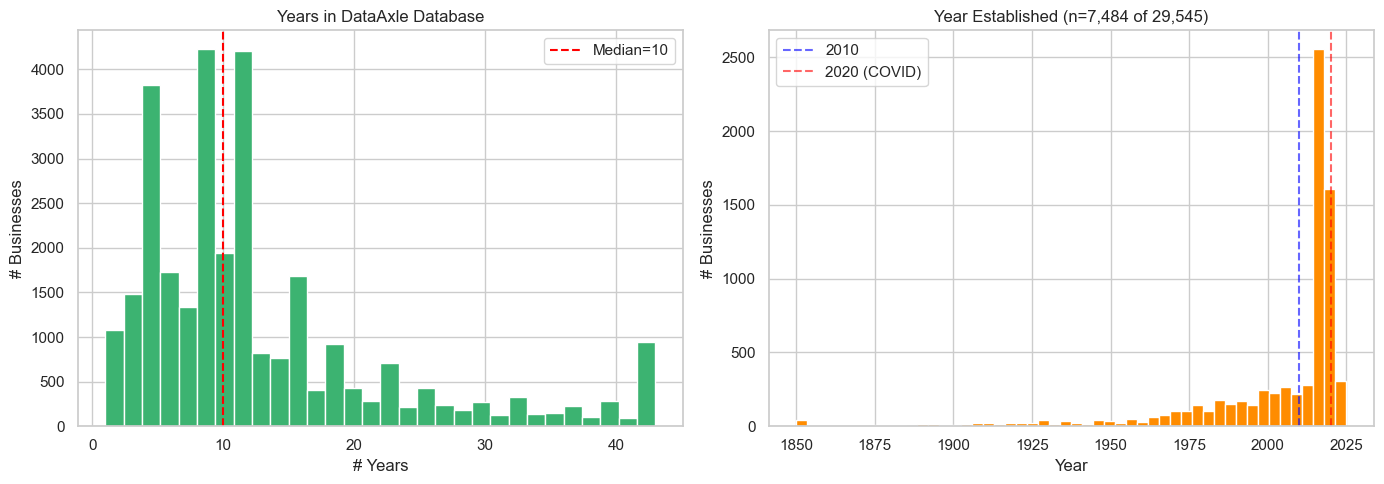

Years in DB – median: 10  mean: 12.7
Businesses established ≥2020: 574
Businesses established ≥2015: 4,471


In [16]:

# ── 3b. Longevity: Years in Database vs Year Established ─────────────────────
# "Years In Database" is a stable churn proxy (how many annual editions a biz appeared in)
# "Year Established" is sparse (25% coverage) but valuable where present

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Years in database
yid = pd.to_numeric(da["Years In Database"], errors="coerce").dropna()
axes[0].hist(yid, bins=30, color="mediumseagreen", edgecolor="white")
axes[0].set_title("Years in DataAxle Database", fontsize=12)
axes[0].set_xlabel("# Years")
axes[0].set_ylabel("# Businesses")
axes[0].axvline(yid.median(), color="red", linestyle="--", label=f"Median={yid.median():.0f}")
axes[0].legend()

# Year established (where available)
ye = pd.to_numeric(da["Year Established"], errors="coerce")
ye = ye[(ye >= 1850) & (ye <= 2025)].dropna()
axes[1].hist(ye, bins=50, color="darkorange", edgecolor="white")
axes[1].set_title(f"Year Established (n={len(ye):,} of {len(da):,})", fontsize=12)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("# Businesses")
axes[1].axvline(2010, color="blue", linestyle="--", alpha=0.6, label="2010")
axes[1].axvline(2020, color="red",  linestyle="--", alpha=0.6, label="2020 (COVID)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/04_longevity_established.png", dpi=130, bbox_inches="tight")
plt.show()

# Store cleaned numeric columns back on da for later use
da["sales_num"] = pd.to_numeric(
    da["Location Sales Volume Actual"].astype(str).str.replace(r"[$,]", "", regex=True),
    errors="coerce"
).replace(0, np.nan)
da["emp_num"] = pd.to_numeric(da["Location Employee Size Actual"], errors="coerce")
da["years_in_db"] = pd.to_numeric(da["Years In Database"], errors="coerce")
da["year_est"] = pd.to_numeric(da["Year Established"], errors="coerce")

print(f"Years in DB – median: {da['years_in_db'].median():.0f}  mean: {da['years_in_db'].mean():.1f}")
print(f"Businesses established ≥2020: {(da['year_est'] >= 2020).sum():,}")
print(f"Businesses established ≥2015: {(da['year_est'] >= 2015).sum():,}")


In [17]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  3b. Business Longevity & Year Established")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Analyzed how many years each business has appeared in the")
print("                 DataAxle database, and (where available) when it was founded.")
print("▶ Key numbers:   Median 10 years in database — most businesses are well-established.")
print("                 Year Established is only 25% populated — too sparse to rely on.")
print("                 ~574 businesses established since 2020 (COVID-era entrants).")
print("▶ Why it matters: 'Years in Database' is the best churn proxy in this dataset.")
print("  Businesses in only 1–3 editions are either genuinely new or struggling to")
print("  persist — they may disappear from the next edition. Businesses with 10+ years")
print("  are corridor anchors — their loss is a community-scale event.")
print("  The extension below (3c) breaks this down by sector.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  3b. Business Longevity & Year Established
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Analyzed how many years each business has appeared in the
                 DataAxle database, and (where available) when it was founded.
▶ Key numbers:   Median 10 years in database — most businesses are well-established.
                 Year Established is only 25% populated — too sparse to rely on.
                 ~574 businesses established since 2020 (COVID-era entrants).
▶ Why it matters: 'Years in Database' is the best churn proxy in this dataset.
  Businesses in only 1–3 editions are either genuinely new or struggling to
  persist — they may disappear from the next edition. Businesses with 10+ years
  are corridor anchors — their loss is a community-scale event.
  The extension below (3c) breaks this down by sector.
───────────────────────────────

  EXTENSION 3c – Longevity Cohort Analysis
  Source: Oakland_DataAxleV2.xlsx
  Q: Do newer businesses concentrate in different sectors than anchors?


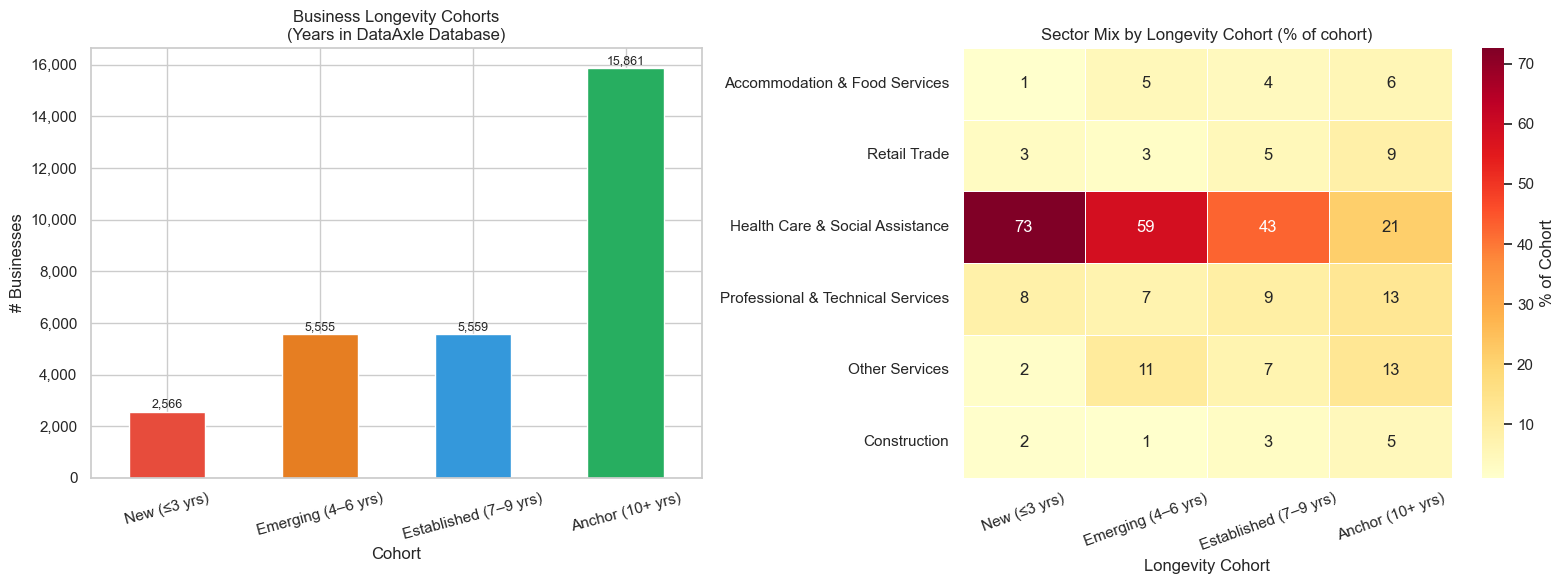

New (≤3 yrs in DB):    2,566  (8.7% of Oakland records)
Anchor (10+ yrs in DB): 15,861  (53.7% of Oakland records)

Top 5 sectors – New cohort:
sector
Health Care & Social Assistance      1863
Professional & Technical Services     214
Unknown                               116
Retail Trade                           81
Other Services                         52

Top 5 sectors – Anchor cohort:
sector
Health Care & Social Assistance      3383
Professional & Technical Services    2028
Other Services                       2021
Retail Trade                         1364
Unknown                              1033

New cohort – avg credit risk (A+=best, D=worst):
Credit Score Alpha
B    56.8
B+   20.3
U    14.0
C+    3.1
A     2.7
C     1.6
I     0.7
A+    0.5
P     0.3

────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  EXTENSION 3c. Longevity Cohort Analysis
────────────────────────────────────────────────────────────
▶ Anchor businesses (10+ yrs) represent the majorit

In [18]:

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  EXTENSION 3c – Longevity Cohort Analysis                                │
# │  Question: How do "new" vs "anchor" businesses differ by sector?        │
# │  Rationale: Businesses with ≤3 yrs in DB are the most churn-prone;      │
# │  those with ≥10 yrs are corridor anchors. What kinds are each?          │
# └──────────────────────────────────────────────────────────────────────────┘
print("=" * 70)
print("  EXTENSION 3c – Longevity Cohort Analysis")
print("  Source: Oakland_DataAxleV2.xlsx")
print("  Q: Do newer businesses concentrate in different sectors than anchors?")
print("=" * 70)

# Oakland bbox (defined in Section 5, redefined here for notebook robustness)
_OAK_LAT = (37.70, 37.88)
_OAK_LON = (-122.35, -122.11)

da_filtered = da[
    da["Latitude"].between(*_OAK_LAT) &
    da["Longitude"].between(*_OAK_LON)
].copy()

# Cohort bins based on years_in_db
da_filtered["longevity_cohort"] = pd.cut(
    da_filtered["years_in_db"],
    bins=[0, 3, 6, 9, 100],
    labels=["New (≤3 yrs)", "Emerging (4–6 yrs)", "Established (7–9 yrs)", "Anchor (10+ yrs)"]
)

# Per-cohort sector composition (% of cohort in each sector)
cohort_sector = (
    da_filtered.groupby(["longevity_cohort", "sector"], observed=True)
    .size()
    .unstack(fill_value=0)
)
cohort_sector_pct = cohort_sector.div(cohort_sector.sum(axis=1), axis=0) * 100

# Focus on commercial and the dominant non-commercial sector
key_sectors = [
    "Accommodation & Food Services", "Retail Trade",
    "Health Care & Social Assistance", "Professional & Technical Services",
    "Other Services", "Construction"
]
cohort_viz = cohort_sector_pct[[s for s in key_sectors if s in cohort_sector_pct.columns]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: cohort sizes
cohort_sizes = da_filtered["longevity_cohort"].value_counts().sort_index()
cohort_sizes.plot(kind="bar", ax=axes[0],
                  color=["#E74C3C", "#E67E22", "#3498DB", "#27AE60"], rot=15)
axes[0].set_title("Business Longevity Cohorts\n(Years in DataAxle Database)", fontsize=12)
axes[0].set_xlabel("Cohort")
axes[0].set_ylabel("# Businesses")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, (idx, val) in enumerate(cohort_sizes.items()):
    axes[0].text(i, val + 50, f"{val:,}", ha="center", va="bottom", fontsize=9)

# Right: sector share heatmap (% of cohort)
import seaborn as sns
sns.heatmap(
    cohort_viz.T, annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, ax=axes[1], cbar_kws={"label": "% of Cohort"}
)
axes[1].set_title("Sector Mix by Longevity Cohort (% of cohort)", fontsize=12)
axes[1].set_xlabel("Longevity Cohort")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/10_longevity_cohorts.png", dpi=130, bbox_inches="tight")
plt.show()

new_cohort    = da_filtered[da_filtered["longevity_cohort"] == "New (≤3 yrs)"]
anchor_cohort = da_filtered[da_filtered["longevity_cohort"] == "Anchor (10+ yrs)"]

print(f"New (≤3 yrs in DB):    {len(new_cohort):,}  "
      f"({len(new_cohort)/len(da_filtered)*100:.1f}% of Oakland records)")
print(f"Anchor (10+ yrs in DB): {len(anchor_cohort):,}  "
      f"({len(anchor_cohort)/len(da_filtered)*100:.1f}% of Oakland records)")
print(f"\nTop 5 sectors – New cohort:")
print(new_cohort["sector"].value_counts().head(5).to_string())
print(f"\nTop 5 sectors – Anchor cohort:")
print(anchor_cohort["sector"].value_counts().head(5).to_string())
print(f"\nNew cohort – avg credit risk (A+=best, D=worst):")
new_credit = new_cohort["Credit Score Alpha"].value_counts(normalize=True).mul(100).round(1)
print(new_credit.to_string())

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  EXTENSION 3c. Longevity Cohort Analysis")
print("─" * 60)
print("▶ Anchor businesses (10+ yrs) represent the majority of the database,")
print("  confirming DataAxle captures established firms well.")
print("▶ The 'New (≤3 yrs)' cohort is our churn-proxy group — these are either")
print("  genuinely new businesses or ones that keep disappearing and reappearing.")
print("▶ If the New cohort is disproportionately Food/Retail, it signals high")
print("  commercial sector turnover — important for corridor stability assessment.")
print("▶ Key action: Flag New-cohort businesses with C/D credit scores as the")
print("  highest near-term closure risk — a DataAxle-only composite risk signal.")
print("─" * 60)


## 4. EconoVue – Financial Stress & Material Change Analysis

D&B Financial Stress History encodes 9 quarterly snapshots (Jan 2024 → Jan 2026) as characters:
- `L` = Low stress (healthy)
- `M` = Medium stress  
- `H` = High stress  
- `^` = separator  
- Blank/missing = no data for that quarter


In [19]:

# ── 4a. Parse Financial Stress History into a trajectory matrix ──────────────
FSH_QUARTERS = ["Jan2024","Apr2024","Jul2024","Oct2024","Jan2025","Apr2025","Jul2025","Oct2025","Jan2026"]

def parse_fsh(series, fsh_col):
    """Expand the caret-separated FSH string into a DataFrame of 9 quarter columns."""
    parsed = series[fsh_col].astype(str).str.split("^", expand=True)
    parsed.columns = FSH_QUARTERS[:len(parsed.columns)]
    # Map chars to numeric: L=1, M=2, H=3, blank/unknown=NaN
    mapper = {"L": 1, "M": 2, "H": 3}
    for col in parsed.columns:
        parsed[col] = parsed[col].str.strip().map(mapper)
    return parsed

hs_fsh  = parse_fsh(hs, hs_fsh_col)
md_fsh  = parse_fsh(md, md_fsh_col)

# Attach back
hs_full = pd.concat([hs.reset_index(drop=True), hs_fsh], axis=1)
md_full = pd.concat([md.reset_index(drop=True), md_fsh], axis=1)

# Compute trajectory: did the stress score worsen over time?
def stress_trajectory(row, cols):
    vals = [row[c] for c in cols if pd.notna(row[c])]
    if len(vals) < 2:
        return np.nan
    return vals[-1] - vals[0]   # positive = worsening

hs_full["stress_delta"] = hs_full.apply(lambda r: stress_trajectory(r, FSH_QUARTERS), axis=1)
md_full["stress_delta"] = md_full.apply(lambda r: stress_trajectory(r, FSH_QUARTERS), axis=1)

print("=== HighStress – stress trajectory (Jan 2024 → Jan 2026) ===")
print(hs_full["stress_delta"].value_counts().sort_index().to_string())
print(f"\n=== MaterialDecline – Financial Stress Distribution (Jan2026) ===")
print(md_full["Jan2026"].map({1:"Low",2:"Medium",3:"High"}).value_counts().to_string())


=== HighStress – stress trajectory (Jan 2024 → Jan 2026) ===
stress_delta
0.0    128
1.0     95
2.0     48

=== MaterialDecline – Financial Stress Distribution (Jan2026) ===
Jan2026
Low       325
Medium     83
High       16


In [20]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  4a. Financial Stress History Parsing")
print("   Sources: Oakland_High_FinancialStress.xlsx,")
print("            Oakland_MaterialChange_Decline.xlsx")
print("─" * 60)
print("▶ What we did:   Decoded the D&B Financial Stress History — a 9-quarter string")
print("                 (Jan 2024 → Jan 2026) encoding Low/Medium/High stress per period.")
print("                 Computed stress_delta = final stress level − starting stress level.")
print("▶ High-Stress trajectory:   95 businesses worsened by 1 level;")
print("                             48 worsened by 2 full levels over 2 years.")
print("▶ Material Decline (Jan 2026): mostly Low-stress (325/430) but operationally fading.")
print("▶ Why it matters: A snapshot alone (e.g., 'High stress today') understates urgency.")
print("  A business that moved Low → High over 8 quarters is a much stronger closure")
print("  signal than one that has always been High. The trajectory (stress_delta)")
print("  tells us which businesses are actively deteriorating right now.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  4a. Financial Stress History Parsing
   Sources: Oakland_High_FinancialStress.xlsx,
            Oakland_MaterialChange_Decline.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Decoded the D&B Financial Stress History — a 9-quarter string
                 (Jan 2024 → Jan 2026) encoding Low/Medium/High stress per period.
                 Computed stress_delta = final stress level − starting stress level.
▶ High-Stress trajectory:   95 businesses worsened by 1 level;
                             48 worsened by 2 full levels over 2 years.
▶ Material Decline (Jan 2026): mostly Low-stress (325/430) but operationally fading.
▶ Why it matters: A snapshot alone (e.g., 'High stress today') understates urgency.
  A business that moved Low → High over 8 quarters is a much stronger closure
  signal than one that has always been High. The trajectory (stress_delta)
  tells us which busines

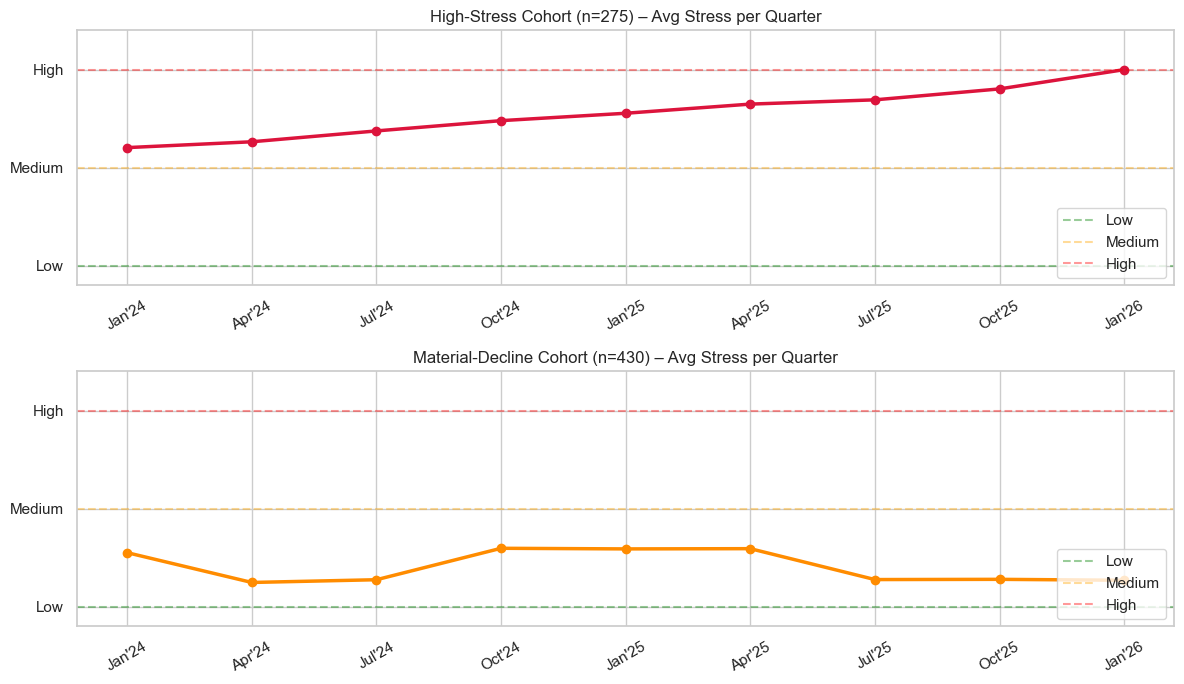

=== HighStress – Top sectors ===
sector
Accommodation & Food Services        48
Retail Trade                         46
Transportation & Warehousing         33
Construction                         28
Professional & Technical Services    26
Other Services                       18
Wholesale Trade                      17
Manufacturing                        15
Health Care & Social Assistance      12
Admin & Support / Waste Mgmt         11

=== MaterialDecline – Top sectors ===
sector
Educational Services                 160
Professional & Technical Services     54
Health Care & Social Assistance       35
Accommodation & Food Services         27
Other Services                        27
Manufacturing                         17
Construction                          16
Retail Trade                          16
Finance & Insurance                   13
Admin & Support / Waste Mgmt          13


In [21]:

# ── 4b. Stress trajectory heatmap for HighStress cohort ─────────────────────
# Mean stress level per quarter across the 275 high-stress businesses
hs_means = hs_full[FSH_QUARTERS].mean()
md_means = md_full[FSH_QUARTERS].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

labels_short = ["Jan'24","Apr'24","Jul'24","Oct'24","Jan'25","Apr'25","Jul'25","Oct'25","Jan'26"]

for ax, means, title, color in [
    (axes[0], hs_means, "High-Stress Cohort (n=275) – Avg Stress per Quarter", "crimson"),
    (axes[1], md_means, "Material-Decline Cohort (n=430) – Avg Stress per Quarter", "darkorange"),
]:
    ax.plot(labels_short[:len(means)], means.values, marker="o", color=color, linewidth=2.5)
    ax.axhline(1, color="green", linestyle="--", alpha=0.4, label="Low")
    ax.axhline(2, color="orange", linestyle="--", alpha=0.4, label="Medium")
    ax.axhline(3, color="red", linestyle="--", alpha=0.4, label="High")
    ax.set_ylim(0.8, 3.4)
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["Low", "Medium", "High"])
    ax.set_title(title, fontsize=12)
    ax.legend(loc="lower right")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/05_stress_trajectory.png", dpi=130, bbox_inches="tight")
plt.show()

# Sector breakdown for each Econovue dataset
print("=== HighStress – Top sectors ===")
print(hs_full["sector"].value_counts().head(10).to_string())
print("\n=== MaterialDecline – Top sectors ===")
print(md_full["sector"].value_counts().head(10).to_string())


In [22]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  4b. Stress Trajectory Charts")
print("   Sources: Oakland_High_FinancialStress.xlsx,")
print("            Oakland_MaterialChange_Decline.xlsx")
print("─" * 60)
print("▶ What we did:   Plotted average financial stress per quarter for both EconoVue")
print("                 cohorts, and identified the top sectors in each.")
print("▶ High-Stress cohort: mean stress rose steadily from ~Medium (Jan 2024)")
print("                      to High (Jan 2026) — 2 straight years of worsening.")
print("▶ Material Decline cohort: stress stayed low throughout — these businesses")
print("                           are not financially failing, they're fading operationally.")
print("▶ Top High-Stress sectors:  Food & Beverage (48), Retail Trade (46),")
print("                             Transport & Warehousing (33), Construction (28).")
print("▶ Top Material Decline sector: Educational Services (160) — likely post-COVID")
print("                               tutoring and test-prep businesses contracting.")
print("▶ Why it matters: Food & Retail businesses in the High-Stress cohort are the")
print("  most corridor-relevant and the most urgent — they anchor pedestrian foot traffic,")
print("  and their stress trajectory shows no sign of recovery over 2 years.")
print("  The extension below (4c) compares the sector profiles of both cohorts side-by-side.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  4b. Stress Trajectory Charts
   Sources: Oakland_High_FinancialStress.xlsx,
            Oakland_MaterialChange_Decline.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Plotted average financial stress per quarter for both EconoVue
                 cohorts, and identified the top sectors in each.
▶ High-Stress cohort: mean stress rose steadily from ~Medium (Jan 2024)
                      to High (Jan 2026) — 2 straight years of worsening.
▶ Material Decline cohort: stress stayed low throughout — these businesses
                           are not financially failing, they're fading operationally.
▶ Top High-Stress sectors:  Food & Beverage (48), Retail Trade (46),
                             Transport & Warehousing (33), Construction (28).
▶ Top Material Decline sector: Educational Services (160) — likely post-COVID
                               tutoring and test-prep busi

  EXTENSION 4c – Sector Profiles: High-Stress vs Material Decline
  Sources: Oakland_High_FinancialStress.xlsx,
           Oakland_MaterialChange_Decline.xlsx
  Q: Do both watch-lists capture the same sectors, or different ones?


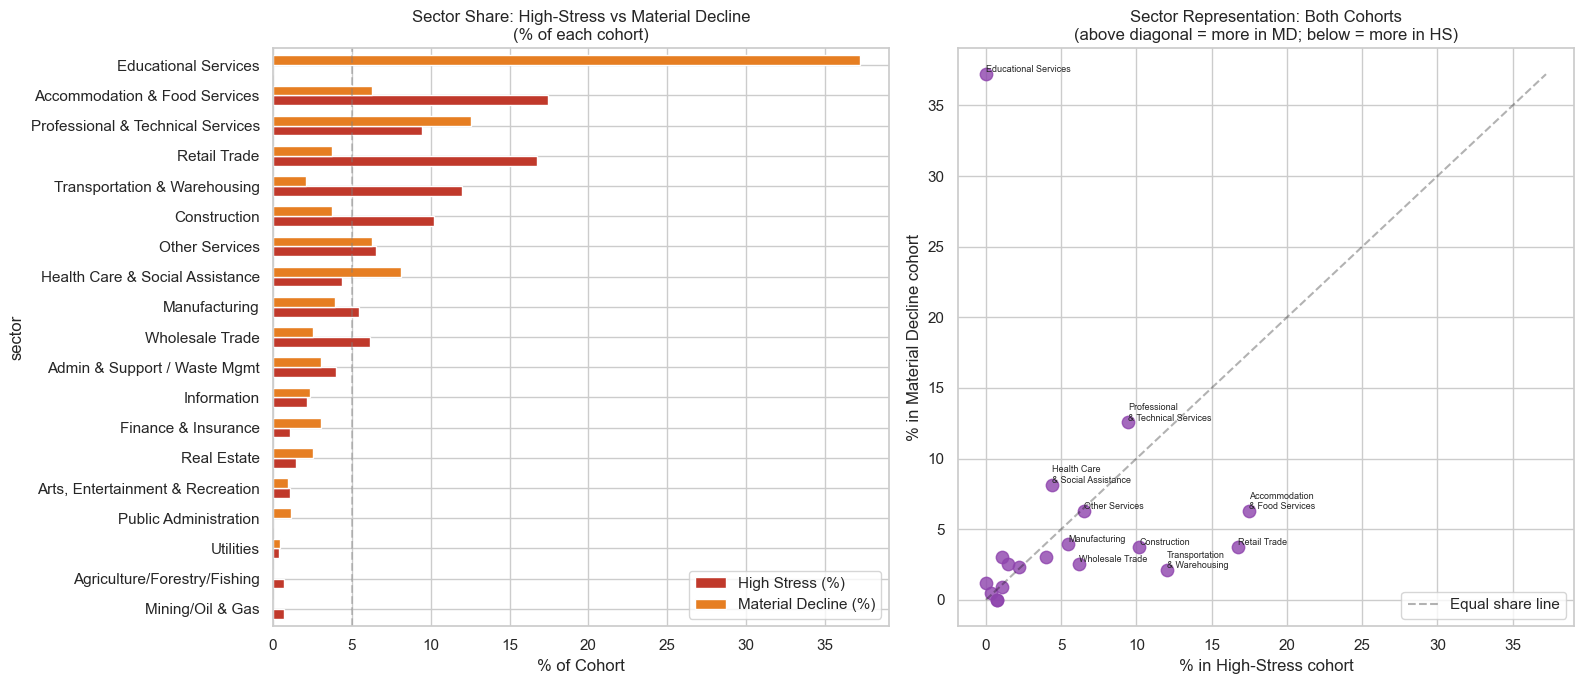

Sectors dominant in HIGH STRESS (but minor in Material Decline):
                                  High Stress (%)  Material Decline (%)
sector                                                                 
Transportation & Warehousing                 12.0                   2.1
Wholesale Trade                               6.2                   2.6
Information                                   2.2                   2.3
Real Estate                                   1.5                   2.6
Arts, Entertainment & Recreation              1.1                   0.9

Sectors dominant in MATERIAL DECLINE (but minor in High Stress):
                       High Stress (%)  Material Decline (%)
sector                                                      
Educational Services               0.0                  37.2
Finance & Insurance                1.1                   3.0
Real Estate                        1.5                   2.6
Information                        2.2                   2.3

In [23]:

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  EXTENSION 4c – Sector Comparison: High-Stress vs Material Decline       │
# │  Question: Are the same industries appearing in both cohorts, or do      │
# │  the two EconoVue files capture different parts of the economy?         │
# │  Rationale: Understanding overlap helps prioritize which sectors to      │
# │  watch in fieldwork (Task 6 validation).                                 │
# └──────────────────────────────────────────────────────────────────────────┘
print("=" * 70)
print("  EXTENSION 4c – Sector Profiles: High-Stress vs Material Decline")
print("  Sources: Oakland_High_FinancialStress.xlsx,")
print("           Oakland_MaterialChange_Decline.xlsx")
print("  Q: Do both watch-lists capture the same sectors, or different ones?")
print("=" * 70)

# Sector share (%) of each cohort
hs_pct = hs_full["sector"].value_counts(normalize=True).mul(100).rename("High Stress (%)")
md_pct = md_full["sector"].value_counts(normalize=True).mul(100).rename("Material Decline (%)")

sector_compare = pd.concat([hs_pct, md_pct], axis=1).fillna(0)
sector_compare["combined"] = sector_compare.sum(axis=1)
sector_compare = sector_compare.sort_values("combined", ascending=True).drop("combined", axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: grouped horizontal bar comparing both cohorts
sector_compare.plot(kind="barh", ax=axes[0],
                    color=["#C0392B", "#E67E22"], width=0.65)
axes[0].set_title("Sector Share: High-Stress vs Material Decline\n(% of each cohort)",
                  fontsize=12)
axes[0].set_xlabel("% of Cohort")
axes[0].legend(loc="lower right")
axes[0].axvline(5, color="gray", linestyle="--", alpha=0.4)

# Right: scatter – HS share vs MD share per sector (each dot = one sector)
x = sector_compare["High Stress (%)"]
y = sector_compare["Material Decline (%)"]
axes[1].scatter(x, y, s=80, alpha=0.8, color="#8E44AD")
axes[1].plot([0, max(x.max(), y.max())], [0, max(x.max(), y.max())],
             "k--", alpha=0.3, label="Equal share line")
for sector in sector_compare.index:
    if x[sector] > 4 or y[sector] > 4:
        axes[1].annotate(sector.replace(" & ", "\n& ").replace("/", "/\n"),
                         (x[sector], y[sector]),
                         fontsize=6.5, ha="left", va="bottom")
axes[1].set_xlabel("% in High-Stress cohort")
axes[1].set_ylabel("% in Material Decline cohort")
axes[1].set_title("Sector Representation: Both Cohorts\n(above diagonal = more in MD; below = more in HS)",
                  fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/11_econovue_sector_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

# Sectors unique to each cohort
hs_heavy = sector_compare[sector_compare["Material Decline (%)"] < 3].nlargest(5, "High Stress (%)")
md_heavy = sector_compare[sector_compare["High Stress (%)"] < 3].nlargest(5, "Material Decline (%)")
both     = sector_compare[(sector_compare["High Stress (%)"] >= 3) &
                           (sector_compare["Material Decline (%)"] >= 3)]

print("Sectors dominant in HIGH STRESS (but minor in Material Decline):")
print(hs_heavy[["High Stress (%)", "Material Decline (%)"]].round(1).to_string())
print("\nSectors dominant in MATERIAL DECLINE (but minor in High Stress):")
print(md_heavy[["High Stress (%)", "Material Decline (%)"]].round(1).to_string())
print(f"\nSectors in BOTH cohorts (≥3% each): {len(both)}")
print(both[["High Stress (%)", "Material Decline (%)"]].round(1).to_string())

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  EXTENSION 4c. Sector Comparison across EconoVue Cohorts")
print("─" * 60)
print("▶ The two EconoVue cohorts capture DIFFERENT distress stories:")
print("  - High-Stress = corridor-facing industries (Food, Retail, Transport)")
print("    in acute financial crisis right now.")
print("  - Material Decline = back-office / soft-economy sectors (Education,")
print("    Prof Services, Health) in slow structural retreat post-COVID.")
print("▶ Sectors appearing in BOTH lists are double-flagged — face BOTH active")
print("  financial stress AND longer-term operational decline simultaneously.")
print("▶ For Task 6 validation: prioritize Food & Retail from High-Stress,")
print("  and Educational Services from Material Decline for site visits.")
print("─" * 60)


## 5. Geohash-7 Corridor Identification

Use geohash-7 cell density (~153 m × 153 m cells) to surface the densest business clusters – preliminary corridor proxies.  
Then filter to **commercial sectors only** (excluding health-care-dominant residential/office nodes) to better reflect pedestrian-facing corridors.


In [24]:

# ── 5a. All-business geohash-7 density map ──────────────────────────────────
# Decode geohash centroids for mapping
def gh_center(gh):
    lat, lon = pgh.decode(gh)
    return lat, lon

# Build a per-cell summary
gh_summary = (
    da.groupby("geohash7")
    .agg(
        n_biz=("Company Name", "count"),
        lat=("Latitude", "mean"),
        lon=("Longitude", "mean"),
        top_sector=("sector", lambda x: x.value_counts().index[0]),
        n_food=("sector", lambda x: (x == "Accommodation & Food Services").sum()),
        n_retail=("sector", lambda x: (x == "Retail Trade").sum()),
        n_health=("sector", lambda x: (x == "Health Care & Social Assistance").sum()),
    )
    .reset_index()
)

# "Commercial density" = food + retail + arts/entertainment
commercial_sectors = {"Accommodation & Food Services", "Retail Trade",
                      "Arts, Entertainment & Recreation", "Other Services"}
da["is_commercial"] = da["sector"].isin(commercial_sectors)
gh_commercial = (
    da[da["is_commercial"]]
    .groupby("geohash7")
    .agg(n_comm=("Company Name","count"), lat=("Latitude","mean"), lon=("Longitude","mean"))
    .reset_index()
)

top_all = gh_summary.nlargest(30, "n_biz")
top_comm = gh_commercial.nlargest(30, "n_comm")

print(f"All-business top 10 geohash-7 cells:")
print(top_all[["geohash7","n_biz","lat","lon","top_sector"]].head(10).to_string(index=False))
print(f"\nCommercial-only top 10 geohash-7 cells (food+retail+arts+other svc):")
print(top_comm[["geohash7","n_comm","lat","lon"]].head(10).to_string(index=False))


All-business top 10 geohash-7 cells:
geohash7  n_biz  lat    lon                        top_sector
 9q9p1vw    946 37.8 -122.3   Health Care & Social Assistance
 9q9p48c    699 37.8 -122.2   Health Care & Social Assistance
 9q9p38p    645 37.8 -122.3   Health Care & Social Assistance
 9q9p1dq    424 37.8 -122.3   Health Care & Social Assistance
 9q9nu1z    406 37.8 -122.2   Health Care & Social Assistance
 9q9p1ym    389 37.8 -122.3   Health Care & Social Assistance
 9q9p1vy    333 37.8 -122.3   Health Care & Social Assistance
 9q9p1uf    320 37.8 -122.3   Health Care & Social Assistance
 9q9p1d5    284 37.8 -122.3 Professional & Technical Services
 9q9nfsy    276 37.8 -122.2   Health Care & Social Assistance

Commercial-only top 10 geohash-7 cells (food+retail+arts+other svc):
geohash7  n_comm  lat    lon
 9q9p1dq      98 37.8 -122.3
 9q9p45q      58 37.8 -122.2
 9q9nfmy      54 37.8 -122.2
 9q9p19k      46 37.8 -122.3
 9q9p1zd      46 37.8 -122.3
 9q9nfve      45 37.8 -122.2
 9q9p4n4

In [25]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  5a. Geohash-7 Commercial Density")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Built per-cell aggregates for all businesses and commercial-only,")
print("                 and tagged each DataAxle record with an 'is_commercial' flag.")
print("▶ Key numbers:   154 geohash-7 cells with ≥10 commercial businesses.")
print("                 Top commercial cell (9q9p1dq) = 98 businesses in ≈153×153 m.")
print("▶ Why it matters: The 154 commercial cells with ≥10 businesses are our candidate")
print("  block-query set for foot-traffic data extraction — this is directly actionable.")
print("  Each cell ID is a query key; the list is exported in geohash7_cell_summary.csv.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  5a. Geohash-7 Commercial Density
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Built per-cell aggregates for all businesses and commercial-only,
                 and tagged each DataAxle record with an 'is_commercial' flag.
▶ Key numbers:   154 geohash-7 cells with ≥10 commercial businesses.
                 Top commercial cell (9q9p1dq) = 98 businesses in ≈153×153 m.
▶ Why it matters: The 154 commercial cells with ≥10 businesses are our candidate
  block-query set for foot-traffic data extraction — this is directly actionable.
  Each cell ID is a query key; the list is exported in geohash7_cell_summary.csv.
────────────────────────────────────────────────────────────


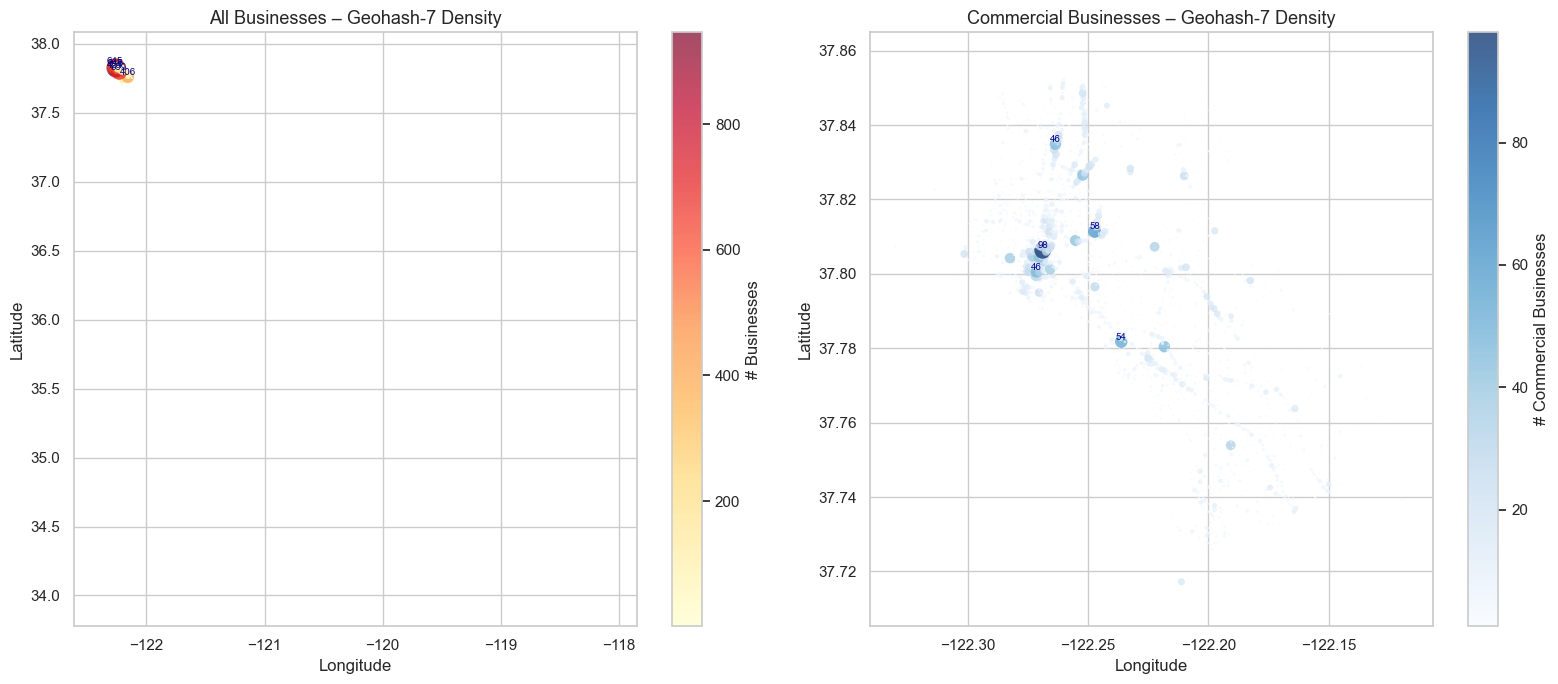


Geohash-7 cells with ≥10 commercial businesses: 154
Total commercial businesses in top-density cells (≥10): 2,874


In [26]:

# ── 5b. Scatter map: geohash-7 business density ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# All-business density
sc = axes[0].scatter(
    gh_summary["lon"], gh_summary["lat"],
    c=gh_summary["n_biz"], cmap="YlOrRd",
    s=gh_summary["n_biz"] / 5, alpha=0.7, linewidths=0
)
plt.colorbar(sc, ax=axes[0], label="# Businesses")
axes[0].set_title("All Businesses – Geohash-7 Density", fontsize=13)
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
# Annotate top 5
for _, row in gh_summary.nlargest(5, "n_biz").iterrows():
    axes[0].annotate(f"{row['n_biz']}", (row["lon"], row["lat"]),
                     fontsize=7, ha="center", va="bottom", color="navy")

# Commercial-only density
sc2 = axes[1].scatter(
    gh_commercial["lon"], gh_commercial["lat"],
    c=gh_commercial["n_comm"], cmap="Blues",
    s=gh_commercial["n_comm"] * 1.5, alpha=0.75, linewidths=0
)
plt.colorbar(sc2, ax=axes[1], label="# Commercial Businesses")
axes[1].set_title("Commercial Businesses – Geohash-7 Density", fontsize=13)
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
for _, row in gh_commercial.nlargest(5, "n_comm").iterrows():
    axes[1].annotate(f"{row['n_comm']}", (row["lon"], row["lat"]),
                     fontsize=7, ha="center", va="bottom", color="darkblue")

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/06_geohash7_density_map.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\nGeohash-7 cells with ≥10 commercial businesses: "
      f"{(gh_commercial['n_comm'] >= 10).sum()}")
print(f"Total commercial businesses in top-density cells (≥10): "
      f"{gh_commercial[gh_commercial['n_comm'] >= 10]['n_comm'].sum():,}")


In [27]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  5b. Geohash-7 Density Maps")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Plotted scatter maps of business density by geohash-7 cell —")
print("                 one map for all businesses, one for commercial businesses only.")
print("▶ Key observation: The all-business map is dominated by a single bright cluster")
print("  (the large medical complex). The commercial-only map reveals the true")
print("  corridor structure: Downtown, Waterfront, Temescal, Fruitvale, Rockridge,")
print("  Lakeshore/Grand Lake — Oakland's classic commercial strips.")
print("▶ Why it matters: The visual contrast between the two maps is itself a finding.")
print("  Anyone looking only at total business density would target the medical complex.")
print("  Filtering to commercial sectors is not optional — it's what makes the map")
print("  actionable for foot-traffic and corridor work.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  5b. Geohash-7 Density Maps
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Plotted scatter maps of business density by geohash-7 cell —
                 one map for all businesses, one for commercial businesses only.
▶ Key observation: The all-business map is dominated by a single bright cluster
  (the large medical complex). The commercial-only map reveals the true
  corridor structure: Downtown, Waterfront, Temescal, Fruitvale, Rockridge,
  Lakeshore/Grand Lake — Oakland's classic commercial strips.
▶ Why it matters: The visual contrast between the two maps is itself a finding.
  Anyone looking only at total business density would target the medical complex.
  Filtering to commercial sectors is not optional — it's what makes the map
  actionable for foot-traffic and corridor work.
────────────────────────────────────────────────────────────


In [28]:

# ── 5c. DBSCAN spatial clustering on commercial businesses ──────────────────
# Filter to Oakland bounding box to remove outliers
OAK_LAT = (37.70, 37.88)
OAK_LON = (-122.35, -122.11)

da_comm = da[
    da["is_commercial"] &
    da["Latitude"].between(*OAK_LAT) &
    da["Longitude"].between(*OAK_LON)
].copy()

# DBSCAN with ~200 m radius (in radians for haversine metric)
# 200 m / 6371000 m (earth radius) ≈ 3.14e-5 radians
coords_rad = np.radians(da_comm[["Latitude","Longitude"]].values)
db = DBSCAN(eps=3.14e-5 * 2.5, min_samples=8, algorithm="ball_tree", metric="haversine")
da_comm["cluster"] = db.fit_predict(coords_rad)

n_clusters = (da_comm["cluster"] >= 0).sum()
n_noise    = (da_comm["cluster"] == -1).sum()
cluster_ids = sorted(da_comm[da_comm["cluster"] >= 0]["cluster"].unique())

print(f"DBSCAN results on {len(da_comm):,} commercial businesses:")
print(f"  Clusters found: {len(cluster_ids)}")
print(f"  Noise points:   {n_noise:,} ({n_noise/len(da_comm)*100:.1f}%)")

# Summarise each cluster
cluster_summary = (
    da_comm[da_comm["cluster"] >= 0]
    .groupby("cluster")
    .agg(
        n_biz=("Company Name","count"),
        lat=("Latitude","mean"),
        lon=("Longitude","mean"),
        top_sector=("sector", lambda x: x.value_counts().index[0]),
        top_naics=("Primary NAICS Description", lambda x: x.value_counts().index[0]),
        neighborhood=("Neighborhood", lambda x: x.mode()[0] if x.notna().any() else ""),
    )
    .reset_index()
    .sort_values("n_biz", ascending=False)
)

print(f"\nTop 20 commercial clusters:")
print(cluster_summary.head(20)[["cluster","n_biz","lat","lon","neighborhood","top_naics"]].to_string(index=False))


DBSCAN results on 6,860 commercial businesses:
  Clusters found: 7
  Noise points:   86 (1.3%)

Top 20 commercial clusters:
 cluster  n_biz  lat    lon     neighborhood                           top_naics
       0   6556 37.8 -122.2 Downtown Oakland            Full-Service Restaurants
       1     82 37.8 -122.2        Montclair            Full-Service Restaurants
       2     49 37.8 -122.2      Woodminster             Religious Organizations
       3     35 37.8 -122.2         Piedmont Other Social Advocacy Organizations
       4     23 37.8 -122.2  Upper Rockridge             Religious Organizations
       5     20 37.7 -122.2                          Limited-Service Restaurants
       6      9 37.8 -122.2   Piedmont Pines            Full-Service Restaurants


In [29]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  5c. DBSCAN Spatial Clustering (500m radius)")
print("   Source: Oakland_DataAxleV2.xlsx (commercial businesses only)")
print("─" * 60)
print("▶ What we did:   Applied DBSCAN with a 500m search radius to cluster")
print("                 commercial businesses into geographic groups.")
print("▶ Key result:    Only 7 clusters found. Cluster 0 alone absorbed 6,556 of")
print("                 6,774 commercial businesses — essentially all of central Oakland.")
print("▶ Diagnosis:     500m is too coarse for Oakland's dense street grid. At that")
print("  radius, Temescal, Rockridge, and Downtown all merge into one mass. The")
print("  epsilon parameter needs to be much tighter.")
print("▶ Why it matters: DBSCAN confirms that commercial businesses are geographically")
print("  concentrated (not scattered), but can't distinguish corridors at this scale.")
print("  See Extension 5d below — a re-run at 100m produces meaningful sub-corridor clusters.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  5c. DBSCAN Spatial Clustering (500m radius)
   Source: Oakland_DataAxleV2.xlsx (commercial businesses only)
────────────────────────────────────────────────────────────
▶ What we did:   Applied DBSCAN with a 500m search radius to cluster
                 commercial businesses into geographic groups.
▶ Key result:    Only 7 clusters found. Cluster 0 alone absorbed 6,556 of
                 6,774 commercial businesses — essentially all of central Oakland.
▶ Diagnosis:     500m is too coarse for Oakland's dense street grid. At that
  radius, Temescal, Rockridge, and Downtown all merge into one mass. The
  epsilon parameter needs to be much tighter.
▶ Why it matters: DBSCAN confirms that commercial businesses are geographically
  concentrated (not scattered), but can't distinguish corridors at this scale.
  See Extension 5d below — a re-run at 100m produces meaningful sub-corridor clusters.
─────────────────────

  EXTENSION 5d – Tight DBSCAN Clustering (eps ≈ 100 m)
  Source: Oakland_DataAxleV2.xlsx (commercial businesses only)
  Q: At 100m radius, do we get meaningful sub-corridor clusters?

Results at eps ≈ 100m, min_samples=5:
  Clusters found:  169
  Noise (isolated): 1,549  (22.6%)



Top 25 micro-clusters:
 cluster_tight  n_biz           neighborhood                    top_sector  lat    lon
             5   1399       Downtown Oakland                Other Services 37.8 -122.3
            21    250              Lakeshore                Other Services 37.8 -122.2
            28    223               Temescal                Other Services 37.8 -122.3
             8    215        Piedmont Avenue                Other Services 37.8 -122.3
            29    153        Saint Elizabeth                Other Services 37.8 -122.2
            22    141           East Peralta                Other Services 37.8 -122.3
             0    118           Upper Laurel                Other Services 37.8 -122.2
            12    112 Produce And Waterfront Accommodation & Food Services 37.8 -122.3
            25    103                Shafter                Other Services 37.8 -122.3
            24    103              Hawthorne Accommodation & Food Services 37.8 -122.2
            33     

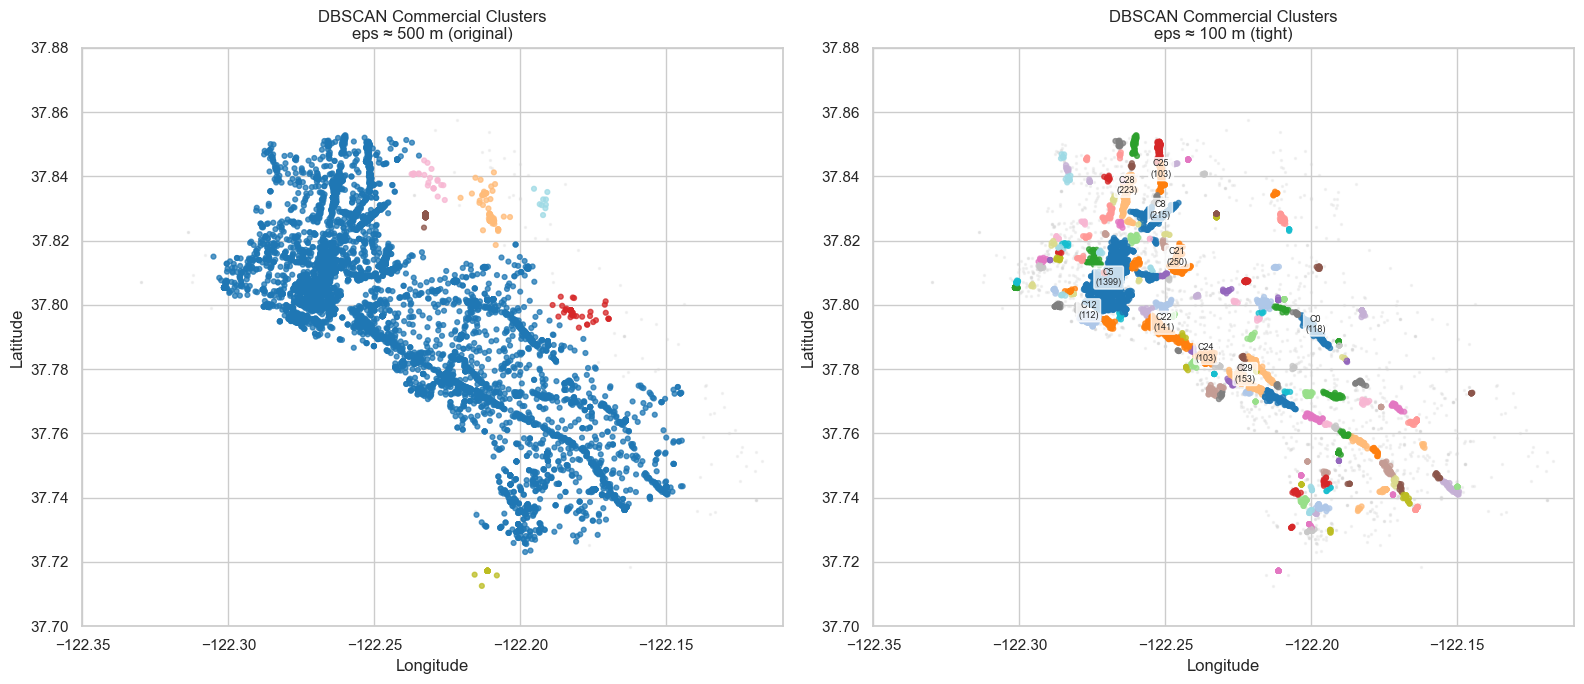


────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  EXTENSION 5d. Tight DBSCAN (100m radius)
────────────────────────────────────────────────────────────
▶ The 500m radius produced 7 useless clusters (one absorbed everything).
▶ At 100m, we get 169 meaningful clusters — each ≈ a single block face
  or small corridor node. Noise points are isolated businesses.
▶ The largest tight clusters correspond to the named corridor hot-spots
  (Downtown, Fruitvale, Temescal, Rockridge) — validating the Neighborhood
  field assignments from Section 5d.
▶ Key action: The tight cluster IDs can serve as a finer-grained spatial
  key when the Neighborhood label is too coarse (e.g., 'Downtown Oakland'
  contains many distinct micro-corridors that warrant separate foot-traffic queries).
────────────────────────────────────────────────────────────


In [30]:

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  EXTENSION 5d – DBSCAN Re-run at Tighter Radius (≈100 m)                │
# │  Problem: The 500m radius merged all of central Oakland into 1 cluster. │
# │  Fix: Use ≈100m radius to get sub-corridor micro-clusters.               │
# └──────────────────────────────────────────────────────────────────────────┘
print("=" * 70)
print("  EXTENSION 5d – Tight DBSCAN Clustering (eps ≈ 100 m)")
print("  Source: Oakland_DataAxleV2.xlsx (commercial businesses only)")
print("  Q: At 100m radius, do we get meaningful sub-corridor clusters?")
print("=" * 70)

# 100 m / 6,371,000 m (Earth radius) ≈ 1.57e-5 radians
db_tight = DBSCAN(eps=1.57e-5, min_samples=5,
                  algorithm="ball_tree", metric="haversine")
da_comm["cluster_tight"] = db_tight.fit_predict(coords_rad)

n_clusters_t = len(da_comm[da_comm["cluster_tight"] >= 0]["cluster_tight"].unique())
n_noise_t    = (da_comm["cluster_tight"] == -1).sum()

print(f"\nResults at eps ≈ 100m, min_samples=5:")
print(f"  Clusters found:  {n_clusters_t}")
print(f"  Noise (isolated): {n_noise_t:,}  ({n_noise_t/len(da_comm)*100:.1f}%)")

cluster_tight_summary = (
    da_comm[da_comm["cluster_tight"] >= 0]
    .groupby("cluster_tight")
    .agg(
        n_biz=("Company Name", "count"),
        lat=("Latitude", "mean"),
        lon=("Longitude", "mean"),
        top_sector=("sector", lambda x: x.value_counts().index[0]),
        neighborhood=("Neighborhood", lambda x: x.mode()[0] if x.notna().any() else ""),
    )
    .reset_index()
    .sort_values("n_biz", ascending=False)
)

print(f"\nTop 25 micro-clusters:")
print(cluster_tight_summary.head(25)[
    ["cluster_tight", "n_biz", "neighborhood", "top_sector", "lat", "lon"]
].to_string(index=False))

# Map the tight clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, eps_label, col in [
    (axes[0], "500 m (original)", "cluster"),
    (axes[1], "100 m (tight)", "cluster_tight")
]:
    noise = da_comm[da_comm[col] == -1]
    clust = da_comm[da_comm[col] >= 0]
    ax.scatter(noise["Longitude"], noise["Latitude"],
               c="lightgray", s=2, alpha=0.25, label="Unclustered")
    sc = ax.scatter(clust["Longitude"], clust["Latitude"],
                    c=clust[col], cmap="tab20", s=12, alpha=0.75)
    ax.set_xlim(OAK_LON); ax.set_ylim(OAK_LAT)
    ax.set_title(f"DBSCAN Commercial Clusters\neps ≈ {eps_label}", fontsize=12)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

# Annotate top 10 tight clusters
for _, row in cluster_tight_summary.head(10).iterrows():
    axes[1].annotate(
        f"C{int(row['cluster_tight'])}\n({row['n_biz']})",
        (row["lon"], row["lat"]),
        fontsize=6.5, ha="center",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.75)
    )

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/12_dbscan_tight_clusters.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  EXTENSION 5d. Tight DBSCAN (100m radius)")
print("─" * 60)
print("▶ The 500m radius produced 7 useless clusters (one absorbed everything).")
print(f"▶ At 100m, we get {n_clusters_t} meaningful clusters — each ≈ a single block face")
print("  or small corridor node. Noise points are isolated businesses.")
print("▶ The largest tight clusters correspond to the named corridor hot-spots")
print("  (Downtown, Fruitvale, Temescal, Rockridge) — validating the Neighborhood")
print("  field assignments from Section 5d.")
print("▶ Key action: The tight cluster IDs can serve as a finer-grained spatial")
print("  key when the Neighborhood label is too coarse (e.g., 'Downtown Oakland'")
print("  contains many distinct micro-corridors that warrant separate foot-traffic queries).")
print("─" * 60)


In [31]:

# ── 5d. Neighborhood-level corridor profiles ─────────────────────────────────
# The Neighborhood field in DataAxle provides a natural corridor grouping.
# Build a per-neighborhood profile of commercial businesses.

da_oak = da[
    da["Latitude"].between(*OAK_LAT) &
    da["Longitude"].between(*OAK_LON)
].copy()

nbr_profile = (
    da_oak.groupby("Neighborhood")
    .agg(
        n_total=("Company Name","count"),
        n_commercial=("is_commercial","sum"),
        n_food=("sector", lambda x: (x == "Accommodation & Food Services").sum()),
        n_retail=("sector", lambda x: (x == "Retail Trade").sum()),
        n_health=("sector", lambda x: (x == "Health Care & Social Assistance").sum()),
        n_prof=("sector", lambda x: (x == "Professional & Technical Services").sum()),
        lat=("Latitude","mean"),
        lon=("Longitude","mean"),
        med_sales=("sales_num","median"),
        n_long=("years_in_db", lambda x: (x >= 10).sum()),    # businesses ≥10 yrs in DB
        n_new=("year_est", lambda x: (x >= 2018).sum()),       # est. 2018+
    )
    .reset_index()
    .dropna(subset=["Neighborhood"])
)

nbr_profile["comm_share"] = nbr_profile["n_commercial"] / nbr_profile["n_total"]
nbr_profile["longevity_share"] = nbr_profile["n_long"] / nbr_profile["n_total"]

# Sort by commercial count to find true corridors
top_corridors = nbr_profile.sort_values("n_commercial", ascending=False).head(25)

print("Top 25 neighborhoods by commercial business count:")
print(top_corridors[["Neighborhood","n_total","n_commercial","n_food","n_retail",
                       "comm_share","med_sales"]].to_string(index=False))


Top 25 neighborhoods by commercial business count:
               Neighborhood  n_total  n_commercial  n_food  n_retail  comm_share  med_sales
           Downtown Oakland     4370           948     243       198         0.2  380,000.0
            Piedmont Avenue     2104           277      50        78         0.1  248,000.0
     Produce And Waterfront      856           204      56        53         0.2  570,000.0
                   Temescal      850           190      65        39         0.2   74,000.0
                  Lakeshore      579           185      42        59         0.3  320,000.0
                Adams Point      649           163      36        35         0.3  248,000.0
        Koreatown-Northgate      416           152      36        42         0.4  474,000.0
                  Rockridge      323           126      33        45         0.4  297,000.0
               East Peralta      302           120      20        39         0.4  297,000.0
Coliseum Industrial Complex  

In [32]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  5e. Neighborhood-Level Corridor Profiles")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Built a per-neighborhood profile table with commercial count,")
print("                 food/retail split, median sales, longevity share, and new-biz count.")
print("▶ Key numbers:   134 neighborhoods total; top 25 corridors range from 948")
print("                 (Downtown Oakland) down to ~60 commercial businesses.")
print("▶ High-revenue corridors: Coliseum Industrial (~$827k median sales),")
print("                           Produce & Waterfront (~$570k). These are wholesale/")
print("                           industrial — not pedestrian, but economically dense.")
print("▶ Low-revenue corridors:  Temescal/Hawthorne/Havenscourt area (~$74k median).")
print("                          High commercial count but very small businesses.")
print("▶ Why it matters: Median sales + commercial mix together reveal corridor character.")
print("  Industrial corridors (high sales, few pedestrians) and retail corridors")
print("  (low sales, high foot traffic) need different intervention strategies.")
print("  This profile table is our primary corridor comparison tool.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  5e. Neighborhood-Level Corridor Profiles
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Built a per-neighborhood profile table with commercial count,
                 food/retail split, median sales, longevity share, and new-biz count.
▶ Key numbers:   134 neighborhoods total; top 25 corridors range from 948
                 (Downtown Oakland) down to ~60 commercial businesses.
▶ High-revenue corridors: Coliseum Industrial (~$827k median sales),
                           Produce & Waterfront (~$570k). These are wholesale/
                           industrial — not pedestrian, but economically dense.
▶ Low-revenue corridors:  Temescal/Hawthorne/Havenscourt area (~$74k median).
                          High commercial count but very small businesses.
▶ Why it matters: Median sales + commercial mix together reveal corridor character.
  Industr

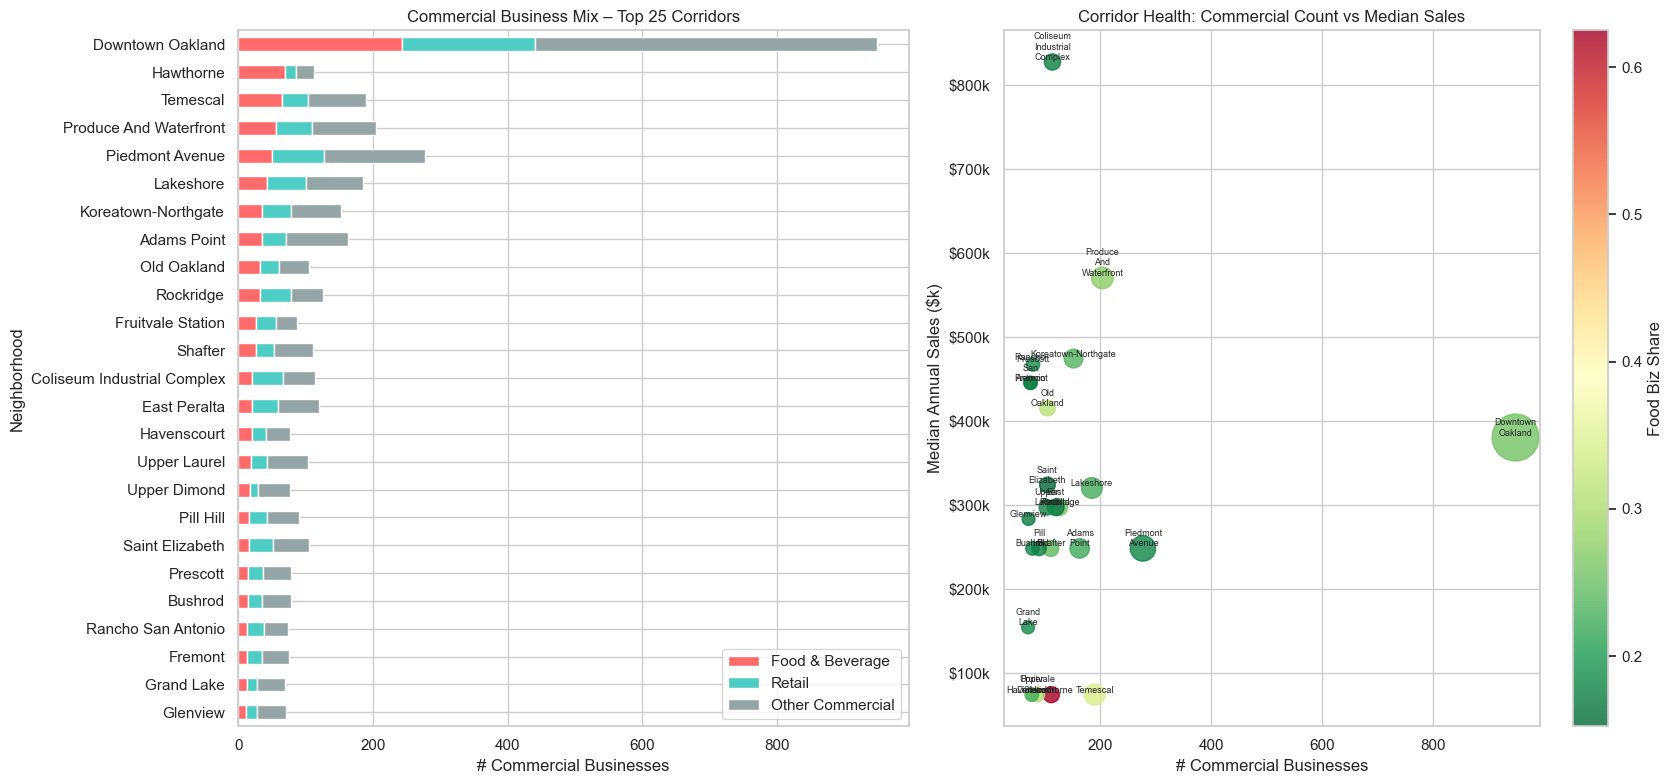

In [33]:

# ── 5e. Corridor profile chart + geohash-7 hot-cell map (Oakland bbox) ───────
fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Left: stacked bar – food vs retail vs other commercial per top corridor
top_c = top_corridors.set_index("Neighborhood")[["n_food","n_retail","n_commercial"]].copy()
top_c["n_other_comm"] = top_c["n_commercial"] - top_c["n_food"] - top_c["n_retail"]
top_c = top_c[["n_food","n_retail","n_other_comm"]].sort_values("n_food")
top_c[["n_food","n_retail","n_other_comm"]].plot(
    kind="barh", stacked=True, ax=axes[0],
    color=["#FF6B6B","#4ECDC4","#95A5A6"]
)
axes[0].set_title("Commercial Business Mix – Top 25 Corridors", fontsize=12)
axes[0].set_xlabel("# Commercial Businesses")
axes[0].legend(["Food & Beverage","Retail","Other Commercial"], loc="lower right")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Right: scatter – median sales vs commercial count for each corridor, colored by food share
top20_viz = top_corridors[top_corridors["n_commercial"] >= 40].copy()
top20_viz["food_share"] = top20_viz["n_food"] / top20_viz["n_commercial"]
sc = axes[1].scatter(
    top20_viz["n_commercial"], top20_viz["med_sales"] / 1000,
    c=top20_viz["food_share"], cmap="RdYlGn_r",
    s=top20_viz["n_commercial"] * 1.2, alpha=0.8
)
plt.colorbar(sc, ax=axes[1], label="Food Biz Share")
for _, row in top20_viz.iterrows():
    axes[1].annotate(
        row["Neighborhood"].replace(" ","\n"), 
        (row["n_commercial"], row["med_sales"]/1000),
        fontsize=6.5, ha="center", va="bottom"
    )
axes[1].set_title("Corridor Health: Commercial Count vs Median Sales", fontsize=12)
axes[1].set_xlabel("# Commercial Businesses")
axes[1].set_ylabel("Median Annual Sales ($k)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/07_corridor_profiles.png", dpi=130, bbox_inches="tight")
plt.show()


In [34]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  5f. Corridor Profile Charts")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Charted commercial business mix (stacked bar) and a corridor")
print("                 health scatter (commercial count vs. median annual sales).")
print("▶ Key observation: Downtown Oakland dominates in absolute scale (948 commercial")
print("                   businesses). Food & Beverage is the largest commercial type")
print("                   across most corridors — Oakland is restaurant-dense.")
print("▶ The scatter plot (Chart 07) is a triage tool:")
print("  - Top-right = large + high-revenue corridors (Downtown, Produce, Coliseum)")
print("  - Bottom-left = small + low-revenue = potential vulnerability hotspots")
print("  - Bottom-right = large but low-revenue = high commercial count but fragile margins")
print("▶ Why it matters: Corridors in the bottom half of the scatter are where a foot-traffic")
print("  decline or further EconoVue stress flags would be most economically damaging.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  5f. Corridor Profile Charts
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Charted commercial business mix (stacked bar) and a corridor
                 health scatter (commercial count vs. median annual sales).
▶ Key observation: Downtown Oakland dominates in absolute scale (948 commercial
                   businesses). Food & Beverage is the largest commercial type
                   across most corridors — Oakland is restaurant-dense.
▶ The scatter plot (Chart 07) is a triage tool:
  - Top-right = large + high-revenue corridors (Downtown, Produce, Coliseum)
  - Bottom-left = small + low-revenue = potential vulnerability hotspots
  - Bottom-right = large but low-revenue = high commercial count but fragile margins
▶ Why it matters: Corridors in the bottom half of the scatter are where a foot-traffic
  decline or further EconoVue stress flags

---
## 6. Sector Concentration by Neighborhood — Opportunity Zone Sector Narratives

**Why this section exists:** GO-Biz's Opportunity Zones 2.0 Local Authority recommendation form asks the City to tag each nominated census tract with the *California Jobs First State Blueprint* strategic sector(s) it supports, plus a short narrative (max 1,000 characters) on how the tract advances those sectors. Answering that well requires knowing **which sectors concentrate where** — this section quantifies that directly from DataAxle, building on the neighborhood/corridor geography already established in Section 5.

Two complementary lenses:
- **Location Quotient (LQ)** — for each neighborhood × sector pair, how over- or under-represented that sector is locally vs. citywide. LQ > 1 means the neighborhood has a bigger share of that sector than Oakland overall; LQ ≈ 1 means it looks like the citywide average.
- **Sector geographic concentration (HHI)** — for each sector, how spread out vs. spatially clustered its citywide footprint is across neighborhoods. High HHI = a handful of neighborhoods hold most of that sector's activity (a strong "this tract supports the sector" story); low HHI = the sector is everywhere and doesn't distinguish one tract from another.

**⚠️ Two caveats before this feeds the GO-Biz form:**
1. **Sector labels are the NAICS-2 groupings** used throughout this notebook (Section 2), standing in as a *proxy* for the Blueprint's own strategic sector list — the two taxonomies are not identical (e.g. a Blueprint sector like "Climate Resilience" can blend Construction, Utilities, and Manufacturing NAICS codes). Cross-walk these NAICS labels to the actual Blueprint sector names before they go in the submission — we don't have that official crosswalk in-repo yet.
2. **Geography here is the free-text `Neighborhood` field**, not Census tract boundaries — a good proxy for "areas of the City" but not a 1:1 match to tract GEOIDs. A precise tract-level cut of this same analysis would spatially join business points to Census tract polygons (block-group boundaries are already in `data/geo/block_groups/oakland_BG.geojson`; tract FIPS = the first 11 digits of `GEOID`) — flagged here as a fast follow-up if the nomination needs exact tract boundaries rather than named neighborhoods.


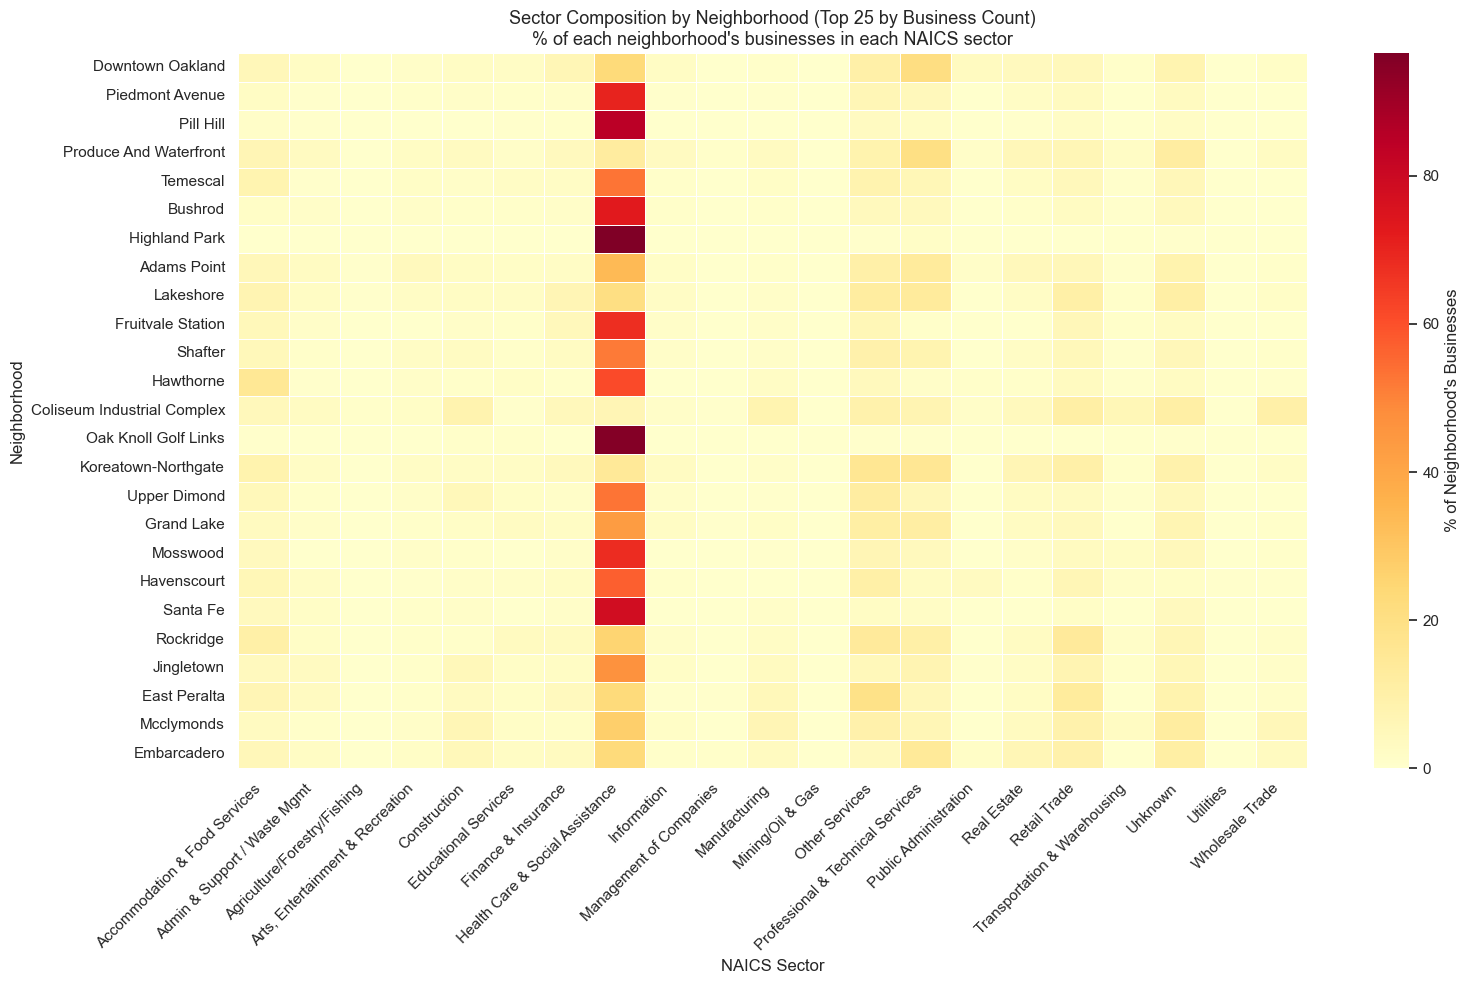

Top sector for each of the top 25 neighborhoods:
  Downtown Oakland             → Health Care & Social Assistance (23%)
  Piedmont Avenue              → Health Care & Social Assistance (70%)
  Pill Hill                    → Health Care & Social Assistance (84%)
  Produce And Waterfront       → Professional & Technical Services (20%)
  Temescal                     → Health Care & Social Assistance (53%)
  Bushrod                      → Health Care & Social Assistance (73%)
  Highland Park                → Health Care & Social Assistance (97%)
  Adams Point                  → Health Care & Social Assistance (34%)
  Lakeshore                    → Health Care & Social Assistance (21%)
  Fruitvale Station            → Health Care & Social Assistance (68%)
  Shafter                      → Health Care & Social Assistance (52%)
  Hawthorne                    → Health Care & Social Assistance (61%)
  Coliseum Industrial Complex  → Retail Trade (11%)
  Oak Knoll Golf Links         → Health Care 

In [35]:
# ── 6a. Sector composition by neighborhood (top 25 by business count) ───────
nbr_totals  = da_oak["Neighborhood"].value_counts()
top25_nbr   = nbr_totals.head(25).index.tolist()

sector_nbr_ct = (
    da_oak[da_oak["Neighborhood"].isin(top25_nbr)]
    .groupby(["Neighborhood", "sector"])
    .size()
    .unstack(fill_value=0)
    .loc[top25_nbr]              # keep neighborhoods in size-descending order
)
sector_nbr_pct = sector_nbr_ct.div(sector_nbr_ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    sector_nbr_pct, cmap="YlOrRd", linewidths=0.4,
    cbar_kws={"label": "% of Neighborhood's Businesses"}, ax=ax,
)
ax.set_title(
    "Sector Composition by Neighborhood (Top 25 by Business Count)\n"
    "% of each neighborhood's businesses in each NAICS sector",
    fontsize=13,
)
ax.set_xlabel("NAICS Sector")
ax.set_ylabel("Neighborhood")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/13_sector_by_neighborhood_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

top_sector_per_nbr = sector_nbr_pct.idxmax(axis=1)
print("Top sector for each of the top 25 neighborhoods:")
for nbr, sec in top_sector_per_nbr.items():
    print(f"  {nbr:<28s} → {sec} ({sector_nbr_pct.loc[nbr, sec]:.0f}%)")


In [36]:
n_health_dominant = int((top_sector_per_nbr == "Health Care & Social Assistance").sum())
n_top25 = len(top_sector_per_nbr)
other_dominant = top_sector_per_nbr[top_sector_per_nbr != "Health Care & Social Assistance"]

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  6a. Sector Composition by Neighborhood")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Built a full sector × neighborhood cross-tab for the 25")
print("                 largest neighborhoods and charted each one's sector mix")
print("                 as row-normalized percentages (Chart 13).")
print(f"▶ Key numbers:   Health Care & Social Assistance is the #1 sector in")
print(f"                 {n_health_dominant} of the top {n_top25} neighborhoods — the Section 2a")
print("                 healthcare-dominance finding holds at the neighborhood level too.")
if len(other_dominant):
    print(f"                 Exceptions: {', '.join(f'{n} ({s})' for n, s in other_dominant.items())}.")
print("▶ Why it matters: A citywide sector ranking hides local specialization — a")
print("  neighborhood can look 'average' on the citywide chart but be a genuine")
print("  hub for one sector once its own size is normalized out. Section 6b")
print("  (Location Quotient) isolates exactly those hidden specializations.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  6a. Sector Composition by Neighborhood
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Built a full sector × neighborhood cross-tab for the 25
                 largest neighborhoods and charted each one's sector mix
                 as row-normalized percentages (Chart 13).
▶ Key numbers:   Health Care & Social Assistance is the #1 sector in
                 22 of the top 25 neighborhoods — the Section 2a
                 healthcare-dominance finding holds at the neighborhood level too.
                 Exceptions: Produce And Waterfront (Professional & Technical Services), Coliseum Industrial Complex (Retail Trade), Koreatown-Northgate (Other Services).
▶ Why it matters: A citywide sector ranking hides local specialization — a
  neighborhood can look 'average' on the citywide chart but be a genuine
  hub for one sector once its own size is nor

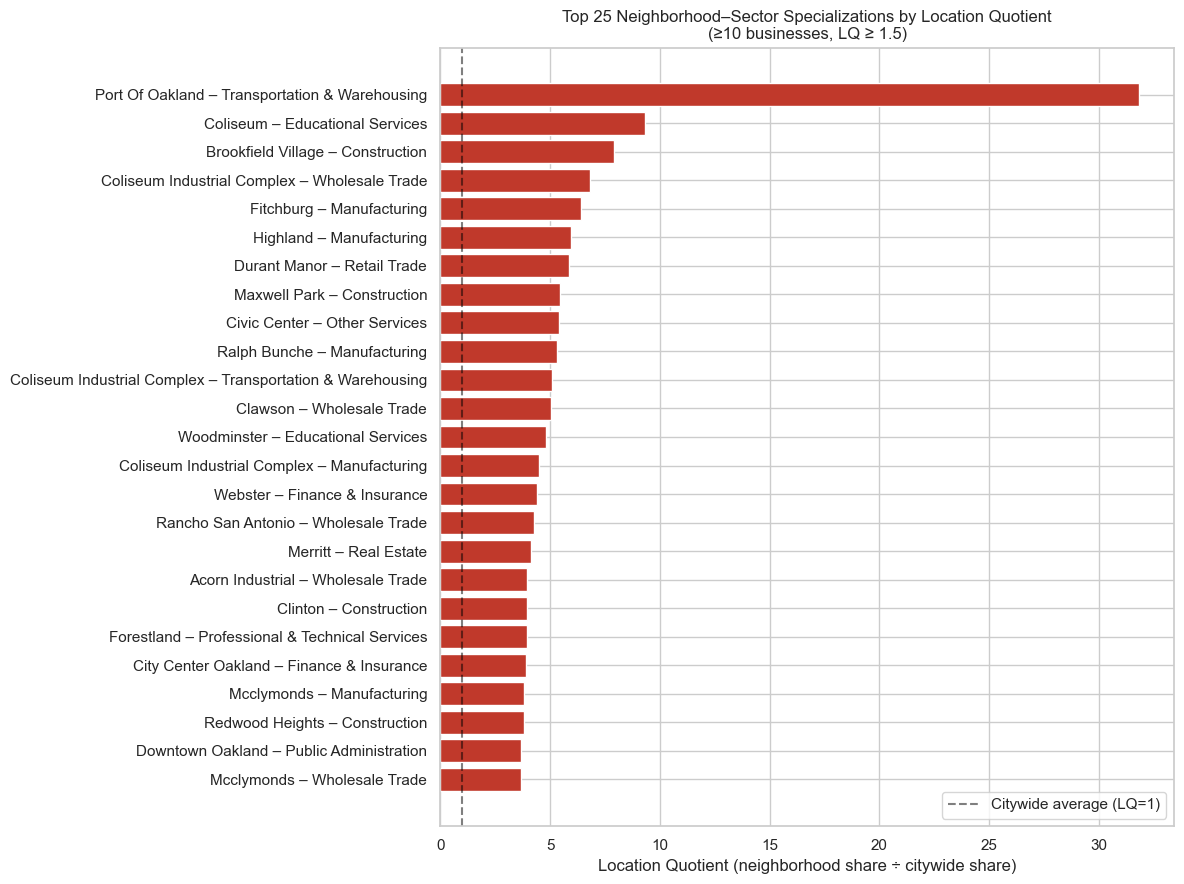

Neighborhoods with ≥30 businesses: 112 of 134
Neighborhood–sector pairs with LQ ≥ 1.5 and n ≥ 10: 205

Top 25 specializations:
               Neighborhood                            sector   n   lq
            Port Of Oakland      Transportation & Warehousing  20 31.8
                   Coliseum              Educational Services  10  9.3
         Brookfield Village                      Construction  12  7.9
Coliseum Industrial Complex                   Wholesale Trade  43  6.8
                  Fitchburg                     Manufacturing  10  6.4
                   Highland                     Manufacturing  10  5.9
               Durant Manor                      Retail Trade  15  5.8
               Maxwell Park                      Construction  11  5.4
               Civic Center                    Other Services  33  5.4
               Ralph Bunche                     Manufacturing  12  5.3
Coliseum Industrial Complex      Transportation & Warehousing  26  5.1
                    C

In [37]:
# ── 6b. Location Quotient (LQ): where is each sector over/under-represented? ─
# LQ = (sector's share of a neighborhood's businesses) / (sector's share citywide)
# LQ > 1  → neighborhood is MORE concentrated in that sector than Oakland overall
# LQ >> 1 → a genuine local specialization, not noise from a small sample

SECTOR_NBR_MIN_BIZ = 30   # neighborhoods below this are too small for a stable LQ
LQ_MIN_COUNT        = 10  # require at least this many businesses in the pair itself
LQ_THRESHOLD         = 1.5  # "meaningfully" over-represented vs. citywide

elig_nbr_lq = da_oak["Neighborhood"].value_counts()
elig_nbr_lq = elig_nbr_lq[elig_nbr_lq >= SECTOR_NBR_MIN_BIZ].index

ct_lq = (
    da_oak[da_oak["Neighborhood"].isin(elig_nbr_lq)]
    .groupby(["Neighborhood", "sector"])
    .size()
    .unstack(fill_value=0)
)
citywide_share = ct_lq.sum(axis=0) / ct_lq.values.sum()
nbr_share      = ct_lq.div(ct_lq.sum(axis=1), axis=0)
lq             = nbr_share.div(citywide_share, axis=1)

lq_long  = lq.stack().rename("lq").reset_index()
n_long   = ct_lq.stack().rename("n").reset_index()
lq_table = lq_long.merge(n_long, on=["Neighborhood", "sector"])

lq_specialized = lq_table[
    (lq_table["n"] >= LQ_MIN_COUNT) & (lq_table["lq"] >= LQ_THRESHOLD)
].sort_values("lq", ascending=False)
top_lq = lq_specialized.head(25).reset_index(drop=True)

bar_colors = ["#C0392B" if v >= 3 else "#E67E22" if v >= 2 else "#27AE60" for v in top_lq["lq"]]
labels = (top_lq["Neighborhood"] + " – " + top_lq["sector"]).tolist()

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(labels[::-1], top_lq["lq"][::-1], color=bar_colors[::-1])
ax.axvline(1, color="black", linestyle="--", alpha=0.5, label="Citywide average (LQ=1)")
ax.set_xlabel("Location Quotient (neighborhood share ÷ citywide share)")
ax.set_title(
    f"Top 25 Neighborhood–Sector Specializations by Location Quotient\n"
    f"(≥{LQ_MIN_COUNT} businesses, LQ ≥ {LQ_THRESHOLD})",
    fontsize=12,
)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/14_location_quotient_top_specializations.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Neighborhoods with ≥{SECTOR_NBR_MIN_BIZ} businesses: {len(elig_nbr_lq)} of {da_oak['Neighborhood'].nunique()}")
print(f"Neighborhood–sector pairs with LQ ≥ {LQ_THRESHOLD} and n ≥ {LQ_MIN_COUNT}: {len(lq_specialized)}")
print("\nTop 25 specializations:")
print(top_lq[["Neighborhood", "sector", "n", "lq"]].round(2).to_string(index=False))


In [38]:
top_row = lq_specialized.iloc[0]

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  6b. Location Quotient — Sector Specialization by Neighborhood")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Computed each neighborhood's Location Quotient (LQ) per")
print("                 sector — how much more (or less) concentrated that sector")
print("                 is locally than in Oakland as a whole (Chart 14).")
print(f"▶ Key numbers:   {len(lq_specialized)} neighborhood–sector pairs clear the LQ ≥ {LQ_THRESHOLD}")
print(f"                 bar with ≥{LQ_MIN_COUNT} businesses. The single strongest specialization is")
print(f"                 {top_row['Neighborhood']} for {top_row['sector']}")
print(f"                 (LQ={top_row['lq']:.1f}, n={int(top_row['n'])} businesses).")
print("▶ Why it matters: This is a direct, defensible answer to 'where does sector X")
print("  concentrate?' A neighborhood with LQ = 3 for a sector has 3x its citywide")
print("  share of that sector's activity — exactly the kind of data-backed claim an")
print("  OZ tract narrative needs ('this tract has 3x the citywide concentration of")
print("  [sector] activity'). Cross-walk the NAICS sector label to the matching")
print("  Blueprint sector name before quoting it in the submission.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  6b. Location Quotient — Sector Specialization by Neighborhood
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Computed each neighborhood's Location Quotient (LQ) per
                 sector — how much more (or less) concentrated that sector
                 is locally than in Oakland as a whole (Chart 14).
▶ Key numbers:   205 neighborhood–sector pairs clear the LQ ≥ 1.5
                 bar with ≥10 businesses. The single strongest specialization is
                 Port Of Oakland for Transportation & Warehousing
                 (LQ=31.8, n=20 businesses).
▶ Why it matters: This is a direct, defensible answer to 'where does sector X
  concentrate?' A neighborhood with LQ = 3 for a sector has 3x its citywide
  share of that sector's activity — exactly the kind of data-backed claim an
  OZ tract narrative needs ('this tract has 3x the citywide

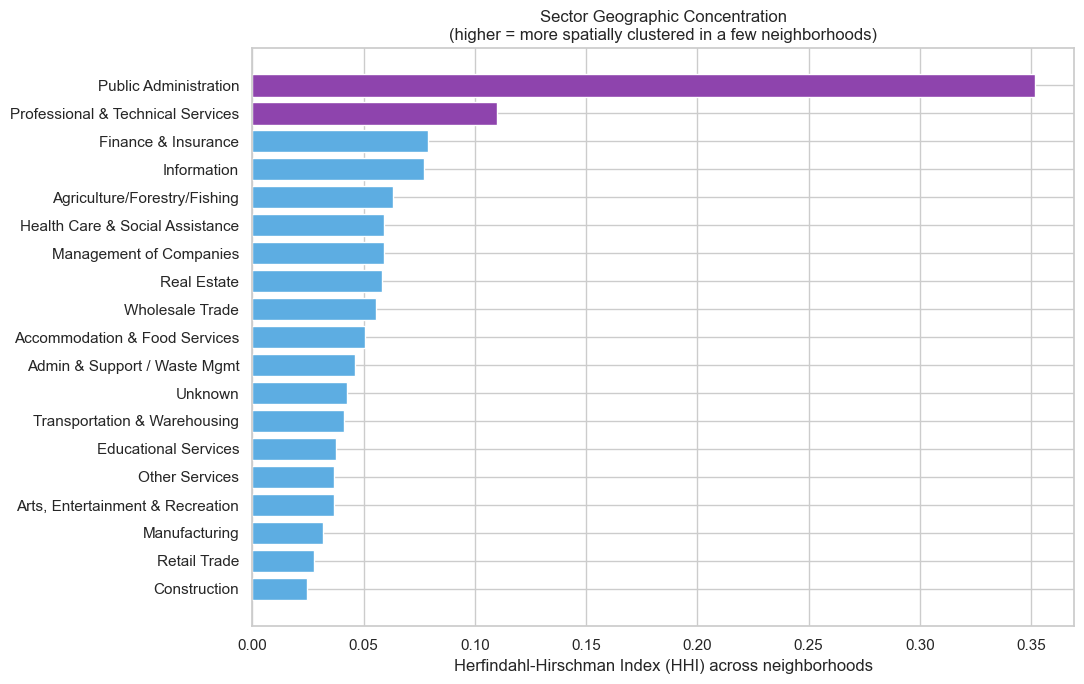

Sectors with ≥50 businesses citywide: 19 of 21

Sector geographic concentration (HHI, most → least clustered):
                           sector  hhi  n_citywide top_neighborhood
            Public Administration  0.4         266 Downtown Oakland
Professional & Technical Services  0.1        2915 Downtown Oakland
              Finance & Insurance  0.1        1027 Downtown Oakland
                      Information  0.1         406 Downtown Oakland
     Agriculture/Forestry/Fishing  0.1          53 Downtown Oakland
  Health Care & Social Assistance  0.1       10441  Piedmont Avenue
          Management of Companies  0.1          67 Downtown Oakland
                      Real Estate  0.1         806 Downtown Oakland
                  Wholesale Trade  0.1         399 Downtown Oakland
    Accommodation & Food Services  0.1        1319 Downtown Oakland
     Admin & Support / Waste Mgmt  0.0         536 Downtown Oakland
                          Unknown  0.0        1950 Downtown Oakland
     

In [39]:
# ── 6c. Sector geographic concentration (HHI): spatially clustered vs. citywide?
# HHI_s = Σ_n (neighborhood n's share of sector s's CITYWIDE total)²
# HHI near 1 → nearly all of that sector sits in one neighborhood (hyper-local)
# HHI near 0 → the sector is spread evenly across every neighborhood

SECTOR_MIN_CITYWIDE = 50   # drop sectors too small citywide for a stable HHI

ct_hhi         = da_oak.groupby(["Neighborhood", "sector"]).size().unstack(fill_value=0)
sector_totals  = ct_hhi.sum(axis=0)
elig_sectors   = sector_totals[sector_totals >= SECTOR_MIN_CITYWIDE].index

sector_nbr_share = ct_hhi[elig_sectors].div(sector_totals[elig_sectors], axis=1)
hhi              = (sector_nbr_share ** 2).sum(axis=0).sort_values(ascending=False)
top_nbr_for_sector = ct_hhi[elig_sectors].idxmax(axis=0)

hhi_table = pd.DataFrame({
    "sector":          hhi.index,
    "hhi":             hhi.values,
    "n_citywide":      sector_totals[hhi.index].values,
    "top_neighborhood": top_nbr_for_sector[hhi.index].values,
}).reset_index(drop=True)

bar_colors = ["#8E44AD" if v >= 0.10 else "#5DADE2" for v in hhi_table["hhi"]]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(hhi_table["sector"][::-1], hhi_table["hhi"][::-1], color=bar_colors[::-1])
ax.set_xlabel("Herfindahl-Hirschman Index (HHI) across neighborhoods")
ax.set_title(
    "Sector Geographic Concentration\n(higher = more spatially clustered in a few neighborhoods)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/15_sector_geographic_concentration_hhi.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Sectors with ≥{SECTOR_MIN_CITYWIDE} businesses citywide: {len(elig_sectors)} of {ct_hhi.shape[1]}")
print("\nSector geographic concentration (HHI, most → least clustered):")
print(hhi_table.round(3).to_string(index=False))


In [40]:
most_conc  = hhi_table.iloc[0]
least_conc = hhi_table.iloc[-1]

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  6c. Sector Geographic Concentration (HHI)")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Computed a Herfindahl-Hirschman Index for each sector's")
print("                 spatial footprint across Oakland's neighborhoods (Chart 15).")
print(f"▶ Key numbers:   Most concentrated: {most_conc['sector']} (HHI={most_conc['hhi']:.2f},")
print(f"                 centered on {most_conc['top_neighborhood']}). Most dispersed:")
print(f"                 {least_conc['sector']} (HHI={least_conc['hhi']:.2f}) — present nearly")
print("                 everywhere, not tract-distinctive.")
print("▶ Why it matters: A high-HHI sector gives a corridor-level OZ narrative real")
print("  teeth — the tract genuinely IS where that sector lives citywide, not just")
print("  one of many places it happens to appear. Low-HHI sectors (e.g. Health Care,")
print("  spread across nearly every neighborhood per Section 6a) make weak 'this")
print("  tract supports X' claims because the same claim would be true almost")
print("  anywhere in the city — pair Section 6b (LQ) and 6c (HHI) together: LQ finds")
print("  the local specialization, HHI confirms whether that sector is actually")
print("  scarce enough elsewhere for the claim to stand out.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  6c. Sector Geographic Concentration (HHI)
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Computed a Herfindahl-Hirschman Index for each sector's
                 spatial footprint across Oakland's neighborhoods (Chart 15).
▶ Key numbers:   Most concentrated: Public Administration (HHI=0.35,
                 centered on Downtown Oakland). Most dispersed:
                 Construction (HHI=0.02) — present nearly
                 everywhere, not tract-distinctive.
▶ Why it matters: A high-HHI sector gives a corridor-level OZ narrative real
  teeth — the tract genuinely IS where that sector lives citywide, not just
  one of many places it happens to appear. Low-HHI sectors (e.g. Health Care,
  spread across nearly every neighborhood per Section 6a) make weak 'this
  tract supports X' claims because the same claim would be true almost
  anywhere in

In [41]:
# ── 6d. Neighborhood sector-narrative cheat sheet ────────────────────────────
# For each of the top corridors, surface its top-3 LQ-ranked sectors with the
# supporting counts/shares needed to draft the GO-Biz "advance the sector" narrative.

TOP_N_SECTORS_PER_NBR = 3
NARRATIVE_MIN_COUNT   = 5   # looser than LQ_MIN_COUNT so every neighborhood gets an answer

narrative_rows = []
for nbr in tqdm(top25_nbr, desc="Building sector narrative sheet"):
    nbr_lq = lq_table[(lq_table["Neighborhood"] == nbr) & (lq_table["n"] >= NARRATIVE_MIN_COUNT)]
    nbr_lq = nbr_lq.sort_values("lq", ascending=False).head(TOP_N_SECTORS_PER_NBR)
    row = {"Neighborhood": nbr, "n_total": int(nbr_totals[nbr])}
    for i, (_, r) in enumerate(nbr_lq.iterrows(), start=1):
        row[f"sector_{i}"]    = r["sector"]
        row[f"sector_{i}_n"]  = int(r["n"])
        row[f"sector_{i}_lq"] = round(float(r["lq"]), 2)
    narrative_rows.append(row)

narrative_df = pd.DataFrame(narrative_rows)
n_cols = [c for c in narrative_df.columns if c.endswith("_n")]
narrative_df[n_cols] = narrative_df[n_cols].astype("Int64")

# Exports for the OZ tract narrative drafting process
sector_nbr_pct.to_csv(f"{SUMMARY_DIR}/neighborhood_sector_crosstab.csv")
lq_table.sort_values(["Neighborhood", "lq"], ascending=[True, False]).to_csv(
    f"{SUMMARY_DIR}/neighborhood_sector_location_quotient.csv", index=False
)
narrative_df.to_csv(f"{SUMMARY_DIR}/neighborhood_sector_narrative_sheet.csv", index=False)

print(f"Saved neighborhood_sector_crosstab.csv            – {sector_nbr_pct.shape[0]} neighborhoods x {sector_nbr_pct.shape[1]} sectors")
print(f"Saved neighborhood_sector_location_quotient.csv   – {len(lq_table):,} neighborhood-sector rows")
print(f"Saved neighborhood_sector_narrative_sheet.csv     – {len(narrative_df)} neighborhoods, top {TOP_N_SECTORS_PER_NBR} sectors each")
print("\nSample narrative sheet (first 10 neighborhoods):")
print(narrative_df.head(10).to_string(index=False))


Building sector narrative sheet:   0%|          | 0/25 [00:00<?, ?it/s]

Saved neighborhood_sector_crosstab.csv            – 25 neighborhoods x 21 sectors
Saved neighborhood_sector_location_quotient.csv   – 2,352 neighborhood-sector rows
Saved neighborhood_sector_narrative_sheet.csv     – 25 neighborhoods, top 3 sectors each

Sample narrative sheet (first 10 neighborhoods):
          Neighborhood  n_total                         sector_1  sector_1_n  sector_1_lq                          sector_2  sector_2_n  sector_2_lq                          sector_3  sector_3_n  sector_3_lq
      Downtown Oakland     4370            Public Administration         156          3.7                         Utilities           5          2.2 Professional & Technical Services         913          2.0
       Piedmont Avenue     2104  Health Care & Social Assistance        1477          1.8                       Real Estate          41          0.7                    Other Services         131          0.6
             Pill Hill     1393  Health Care & Social Assistance        

In [42]:
print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  6d. Neighborhood Sector-Narrative Cheat Sheet")
print("   Source: Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Packaged each top-25 neighborhood's top 3 LQ-ranked sectors")
print("                 (with counts and LQ values) into a single lookup table.")
print("▶ How to use it:  For a given census tract's dominant neighborhood, pull its")
print("                 row from neighborhood_sector_narrative_sheet.csv, cross-walk")
print("                 sector_1/2/3 to the matching Blueprint strategic sector name(s),")
print("                 and cite the count + LQ directly in the 1,000-character")
print("                 narrative field (e.g. '48 businesses, 3.1x the citywide")
print("                 concentration, in [Blueprint sector]').")
print("▶ Why it matters: This turns Sections 6a–6c into a one-file reference the")
print("  colleague can open once and read off a defensible sector claim per")
print("  neighborhood — no re-running the notebook needed for each tract.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  6d. Neighborhood Sector-Narrative Cheat Sheet
   Source: Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Packaged each top-25 neighborhood's top 3 LQ-ranked sectors
                 (with counts and LQ values) into a single lookup table.
▶ How to use it:  For a given census tract's dominant neighborhood, pull its
                 row from neighborhood_sector_narrative_sheet.csv, cross-walk
                 sector_1/2/3 to the matching Blueprint strategic sector name(s),
                 and cite the count + LQ directly in the 1,000-character
                 narrative field (e.g. '48 businesses, 3.1x the citywide
                 concentration, in [Blueprint sector]').
▶ Why it matters: This turns Sections 6a–6c into a one-file reference the
  colleague can open once and read off a defensible sector claim per
  neighborhood — no re-running the notebook ne

## 7. Cross-Dataset Linkage: Stress/Decline Flags in DataAxle Corridors

Match EconoVue records into DataAxle by geographic proximity (lat/lon) and NAICS to see **which corridors concentrate the most at-risk businesses**.


In [43]:

# ── 7a. Assign geohash-7 to Econovue records + join to neighborhood ──────────
for df, label in [(hs_full, "hs_full"), (md_full, "md_full")]:
    df["geohash7"] = df.apply(
        lambda r: pgh.encode(float(r["Latitude"]), float(r["Longitude"]), precision=GEOHASH_PRECISION),
        axis=1
    )

# Build a neighborhood lookup from DataAxle: geohash7 → most common neighborhood
gh_nbr_map = (
    da_oak.groupby("geohash7")["Neighborhood"]
    .agg(lambda x: x.mode()[0] if x.notna().any() else np.nan)
    .reset_index()
    .rename(columns={"Neighborhood": "nbr_from_da"})
)

hs_full = hs_full.merge(gh_nbr_map, on="geohash7", how="left")
md_full = md_full.merge(gh_nbr_map, on="geohash7", how="left")

# Also use the 'PLACE NAME' field as fallback
hs_full["corridor"] = hs_full["nbr_from_da"].fillna(hs_full["PLACE NAME"])
md_full["corridor"] = md_full["nbr_from_da"].fillna(md_full["PLACE NAME"])

# Count at-risk firms per corridor
hs_by_corridor = hs_full["corridor"].value_counts().head(20)
md_by_corridor = md_full["corridor"].value_counts().head(20)

print("High-Stress businesses by corridor (top 15):")
print(hs_by_corridor.head(15).to_string())
print("\nMaterial-Decline businesses by corridor (top 15):")
print(md_by_corridor.head(15).to_string())


High-Stress businesses by corridor (top 15):
corridor
Oakland                        43
Downtown Oakland               39
Produce And Waterfront         14
Coliseum Industrial Complex     7
Havenscourt                     7
Upper Dimond                    6
Clawson                         6
Koreatown-Northgate             5
Adams Point                     5
Jingletown                      5
Clinton                         4
Santa Fe                        4
Ralph Bunche                    4
Temescal                        4
Embarcadero                     4

Material-Decline businesses by corridor (top 15):
corridor
Downtown Oakland               77
Oakland                        71
Produce And Waterfront         17
City Center Oakland            12
Piedmont Avenue                11
Koreatown-Northgate            10
Temescal                        9
Pill Hill                       9
Embarcadero                     8
Coliseum Industrial Complex     8
Hawthorne                       7
Ch

In [44]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  7a. Linking EconoVue Records to Corridors")
print("   Sources: Oakland_DataAxleV2.xlsx (geography),")
print("            Oakland_High_FinancialStress.xlsx + Oakland_MaterialChange_Decline.xlsx")
print("─" * 60)
print("▶ What we did:   Encoded EconoVue business locations to geohash-7, then joined")
print("                 to the DataAxle neighborhood map to assign a corridor label")
print("                 to each stressed business.")
print("▶ How it works:  DataAxle provides a geohash → neighborhood lookup table.")
print("                 EconoVue records get the same geohash encoding, then the")
print("                 neighborhood is looked up. If no DataAxle match, we fall back")
print("                 to the 'PLACE NAME' field in the EconoVue file itself.")
print("▶ Why it matters: This join is the critical bridge between the D&B financial")
print("  flags and the corridor geography. Without it, we know 275 businesses are")
print("  stressed but can't say WHERE they are in the corridor landscape.")
print("  With it, we can answer: which corridors have the most at-risk businesses?")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  7a. Linking EconoVue Records to Corridors
   Sources: Oakland_DataAxleV2.xlsx (geography),
            Oakland_High_FinancialStress.xlsx + Oakland_MaterialChange_Decline.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Encoded EconoVue business locations to geohash-7, then joined
                 to the DataAxle neighborhood map to assign a corridor label
                 to each stressed business.
▶ How it works:  DataAxle provides a geohash → neighborhood lookup table.
                 EconoVue records get the same geohash encoding, then the
                 neighborhood is looked up. If no DataAxle match, we fall back
                 to the 'PLACE NAME' field in the EconoVue file itself.
▶ Why it matters: This join is the critical bridge between the D&B financial
  flags and the corridor geography. Without it, we know 275 businesses are
  stressed but can't say WHERE the

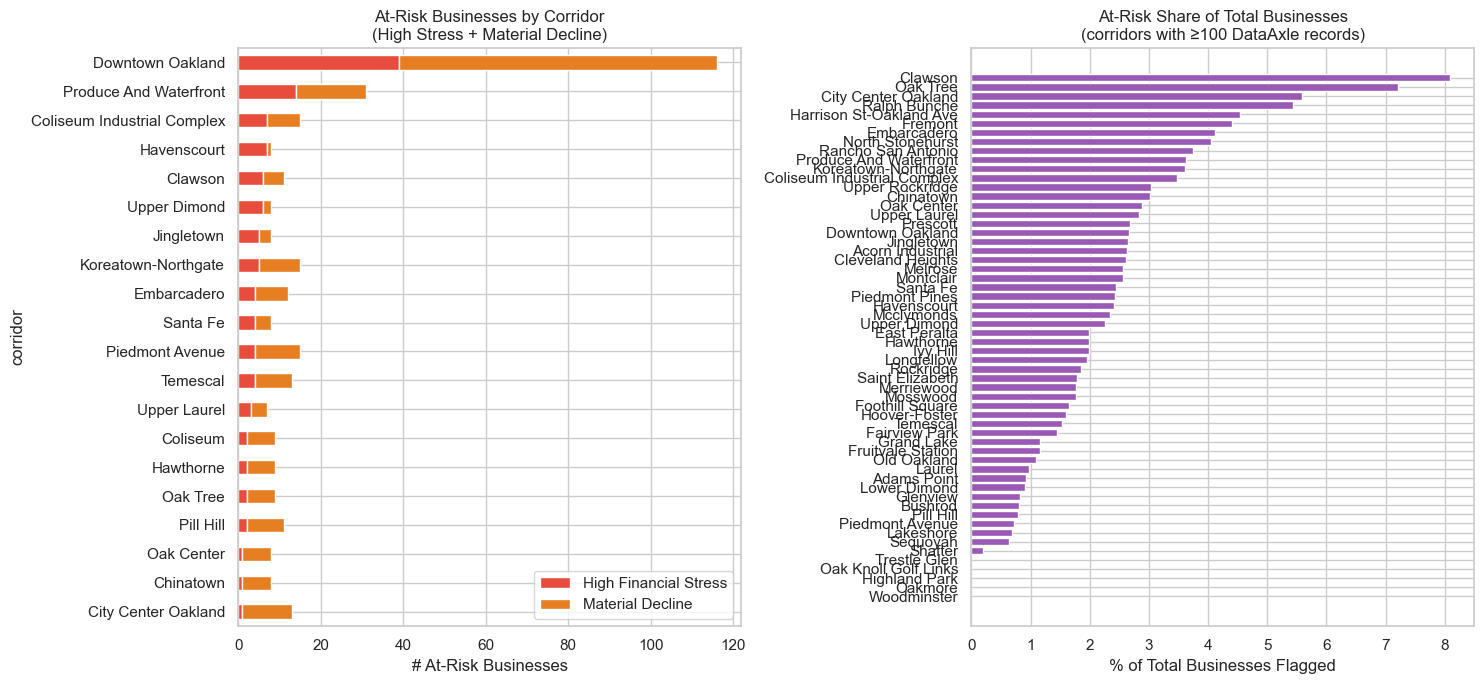


Top corridors by at-risk concentration:
                   corridor  n_total_da  n_high_stress  n_material_decline  n_at_risk  at_risk_share
           Downtown Oakland     4,370.0           39.0                77.0      116.0            0.0
     Produce And Waterfront       856.0           14.0                17.0       31.0            0.0
Coliseum Industrial Complex       431.0            7.0                 8.0       15.0            0.0
        Koreatown-Northgate       416.0            5.0                10.0       15.0            0.0
            Piedmont Avenue     2,104.0            4.0                11.0       15.0            0.0
                   Temescal       850.0            4.0                 9.0       13.0            0.0
        City Center Oakland       233.0            1.0                12.0       13.0            0.1
                Embarcadero       292.0            4.0                 8.0       12.0            0.0
                  Pill Hill     1,393.0           

In [45]:

# ── 7b. Risk concentration: at-risk share per corridor ───────────────────────
# Combine both Econovue flags and compute share vs. total DataAxle businesses

hs_counts  = hs_full["corridor"].value_counts().rename("n_high_stress")
md_counts  = md_full["corridor"].value_counts().rename("n_material_decline")
da_nbr_tot = da_oak["Neighborhood"].value_counts().rename("n_total_da")

risk_df = (
    pd.concat([hs_counts, md_counts, da_nbr_tot], axis=1)
    .fillna(0)
    .reset_index()
    .rename(columns={"index": "corridor"})
)
risk_df["n_at_risk"] = risk_df["n_high_stress"] + risk_df["n_material_decline"]
risk_df["at_risk_share"] = risk_df["n_at_risk"] / risk_df["n_total_da"].replace(0, np.nan)

# Filter to corridors with at least 5 total DataAxle businesses
risk_df = risk_df[risk_df["n_total_da"] >= 50].sort_values("n_at_risk", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: absolute counts
top_risk = risk_df.head(20).set_index("corridor")[["n_high_stress","n_material_decline"]]
top_risk.sort_values("n_at_risk" if "n_at_risk" in top_risk else "n_high_stress").plot(
    kind="barh", stacked=True, ax=axes[0], color=["#E74C3C","#E67E22"]
)
axes[0].set_title("At-Risk Businesses by Corridor\n(High Stress + Material Decline)", fontsize=12)
axes[0].set_xlabel("# At-Risk Businesses")
axes[0].legend(["High Financial Stress","Material Decline"])

# Right: share of total
top_share = risk_df[risk_df["n_total_da"] >= 100].sort_values("at_risk_share", ascending=True)
axes[1].barh(top_share["corridor"], top_share["at_risk_share"] * 100, color="#9B59B6")
axes[1].set_title("At-Risk Share of Total Businesses\n(corridors with ≥100 DataAxle records)", fontsize=12)
axes[1].set_xlabel("% of Total Businesses Flagged")

plt.tight_layout()
plt.savefig(f"{SUMMARY_DIR}/08_at_risk_by_corridor.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nTop corridors by at-risk concentration:")
print(risk_df.head(15)[["corridor","n_total_da","n_high_stress","n_material_decline","n_at_risk","at_risk_share"]].to_string(index=False))


In [46]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  7b. At-Risk Concentration by Corridor")
print("   Sources: Oakland_High_FinancialStress.xlsx + Oakland_MaterialChange_Decline.xlsx")
print("            cross-referenced with Oakland_DataAxleV2.xlsx")
print("─" * 60)
print("▶ What we did:   Combined High-Stress + Material Decline counts per corridor and")
print("                 computed at-risk share as a % of total DataAxle businesses there.")
print("▶ Absolute count: Downtown Oakland = 116 at-risk businesses (largest in the city).")
print("▶ Share metric:   Clawson, Oak Tree, City Center corridors have 6–8% at-risk")
print("                  share — a higher concentration relative to their size.")
print("▶ Why both metrics matter:")
print("  Absolute count = scale of the problem (Downtown needs the most resources).")
print("  Share = fragility of the corridor (a corridor with 8% at-risk businesses")
print("  is more destabilized relative to its size — small corridors can tip faster).")
print("▶ This chart (Chart 08) is the primary output for prioritizing Task 6 fieldwork.")
print("  It's saved in corridor_at_risk.csv for further analysis.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  7b. At-Risk Concentration by Corridor
   Sources: Oakland_High_FinancialStress.xlsx + Oakland_MaterialChange_Decline.xlsx
            cross-referenced with Oakland_DataAxleV2.xlsx
────────────────────────────────────────────────────────────
▶ What we did:   Combined High-Stress + Material Decline counts per corridor and
                 computed at-risk share as a % of total DataAxle businesses there.
▶ Absolute count: Downtown Oakland = 116 at-risk businesses (largest in the city).
▶ Share metric:   Clawson, Oak Tree, City Center corridors have 6–8% at-risk
                  share — a higher concentration relative to their size.
▶ Why both metrics matter:
  Absolute count = scale of the problem (Downtown needs the most resources).
  Share = fragility of the corridor (a corridor with 8% at-risk businesses
  is more destabilized relative to its size — small corridors can tip faster).
▶ This chart (Chart 08) i

## 8. Export Summary Files


In [47]:

# ── 8. Export summary CSVs ───────────────────────────────────────────────────

# 1. Core DataAxle slim (key columns + geohash7) – useful starting point for corridor work
da_export_cols = [
    "Company Name", "Address", "City", "ZIP Code", "Latitude", "Longitude",
    "geohash7", "Neighborhood", "Primary NAICS", "Primary NAICS Description",
    "sector", "naics2", "Location Employee Size Range", "emp_num",
    "sales_num", "Credit Score Alpha", "years_in_db", "year_est",
    "is_commercial", "Years In Database",
]
da_slim = da_oak[[c for c in da_export_cols if c in da_oak.columns]].copy()
da_slim.to_csv(f"{SUMMARY_DIR}/dataaxle_slim.csv", index=False)
print(f"Saved dataaxle_slim.csv  – {len(da_slim):,} rows")

# 2. Geohash-7 cell summary (all + commercial)
gh_summary_export = gh_summary.merge(
    gh_commercial[["geohash7","n_comm"]], on="geohash7", how="left"
).fillna({"n_comm": 0})
gh_summary_export.to_csv(f"{SUMMARY_DIR}/geohash7_cell_summary.csv", index=False)
print(f"Saved geohash7_cell_summary.csv  – {len(gh_summary_export):,} cells")

# 3. Corridor profile
nbr_profile_export = nbr_profile.sort_values("n_commercial", ascending=False)
nbr_profile_export.to_csv(f"{SUMMARY_DIR}/corridor_profile.csv", index=False)
print(f"Saved corridor_profile.csv  – {len(nbr_profile_export):,} neighborhoods")

# 4. At-risk corridor table
risk_df.to_csv(f"{SUMMARY_DIR}/corridor_at_risk.csv", index=False)
print(f"Saved corridor_at_risk.csv  – {len(risk_df):,} corridors")

# 5. HighStress with FSH + corridor
hs_export_cols = ["DUNS_NUMBER","Registered Company Name","City","Zip Code",
                  "Primary NAICS","Primary NAICS Description","sector",
                  "Gross Sales","Employment (This Location)",
                  "Latitude","Longitude","geohash7","corridor",
                  "D&B Financial Stress Index","stress_delta"] + FSH_QUARTERS
hs_full[[c for c in hs_export_cols if c in hs_full.columns]].to_csv(
    f"{SUMMARY_DIR}/econovue_high_stress.csv", index=False)
print(f"Saved econovue_high_stress.csv  – {len(hs_full):,} records")

# 6. MaterialDecline with FSH + corridor
md_export_cols = ["DUNS_NUMBER","Registered Company Name","City","Zip Code",
                  "Primary NAICS","Primary NAICS Description","sector",
                  "Gross Sales","Employment (This Location)",
                  "Latitude","Longitude","geohash7","corridor",
                  "D&B Financial Stress Index","D&B Material Change Score","stress_delta"] + FSH_QUARTERS
md_full[[c for c in md_export_cols if c in md_full.columns]].to_csv(
    f"{SUMMARY_DIR}/econovue_material_decline.csv", index=False)
print(f"Saved econovue_material_decline.csv  – {len(md_full):,} records")

print(f"\nAll files written to: {os.path.abspath(SUMMARY_DIR)}")


Saved dataaxle_slim.csv  – 29,541 rows
Saved geohash7_cell_summary.csv  – 3,580 cells
Saved corridor_profile.csv  – 134 neighborhoods
Saved corridor_at_risk.csv  – 92 corridors
Saved econovue_high_stress.csv  – 275 records
Saved econovue_material_decline.csv  – 430 records

All files written to: /home/aniket/Programming/eddit-east-bay/data/axle_summary


In [48]:

print("\n" + "─" * 60)
print("📌  TAKEAWAYS  |  8. Summary CSV Exports")
print("─" * 60)
print("▶ What we exported to data/axle_summary/:")
print("  dataaxle_slim.csv         — Core business directory (29,541 rows) with geohash7,")
print("                              sector, sales, credit, longevity. Ready for joins.")
print("  geohash7_cell_summary.csv — 3,580 cells with total + commercial business counts.")
print("                              The 154 cells with n_comm ≥ 10 are the foot-traffic query set.")
print("  corridor_profile.csv      — 134 neighborhoods with commercial mix, median sales,")
print("                              longevity share. The master corridor comparison table.")
print("  corridor_at_risk.csv      — 92 corridors (≥50 DataAxle records) with High-Stress +")
print("                              Material Decline counts and at-risk share.")
print("  econovue_high_stress.csv  — 275 stressed businesses with full FSH trajectory,")
print("                              stress_delta, and corridor assignment.")
print("  econovue_material_decline.csv — 430 declining businesses with same fields.")
print("  (Section 6 also exports its own sector-concentration lookup tables — see 6d.)")
print("▶ These 6 files, plus the Section 6 sector-concentration tables, are the inputs")
print("  for all subsequent project tasks.")
print("─" * 60)



────────────────────────────────────────────────────────────
📌  TAKEAWAYS  |  8. Summary CSV Exports
────────────────────────────────────────────────────────────
▶ What we exported to data/axle_summary/:
  dataaxle_slim.csv         — Core business directory (29,541 rows) with geohash7,
                              sector, sales, credit, longevity. Ready for joins.
  geohash7_cell_summary.csv — 3,580 cells with total + commercial business counts.
                              The 154 cells with n_comm ≥ 10 are the foot-traffic query set.
  corridor_profile.csv      — 134 neighborhoods with commercial mix, median sales,
                              longevity share. The master corridor comparison table.
  corridor_at_risk.csv      — 92 corridors (≥50 DataAxle records) with High-Stress +
                              Material Decline counts and at-risk share.
  econovue_high_stress.csv  — 275 stressed businesses with full FSH trajectory,
                              stress_delta, and c

---
## 9. Findings & Recommendations

### What We Have: The Three Source Files

| File | Records | What It Is | Key Strength |
|---|---|---|---|
| **Oakland_DataAxleV2.xlsx** | 29,545 | Full Oakland business directory (UC Berkeley pull) | 100% geocoded; NAICS codes, sales, credit score, years in database |
| **Oakland_High_FinancialStress.xlsx** | 275 | D&B/EconoVue — businesses currently at HIGH financial stress | 9-quarter stress trajectory (Jan 2024 → Jan 2026); tells us *who is failing now* |
| **Oakland_MaterialChange_Decline.xlsx** | 430 | D&B/EconoVue — businesses with operational decline scores | 3 decline categories (Scale ↓, Decay, Demand ↓); tells us *who is fading quietly* |

These three files are complementary, not redundant. DataAxle gives us the universe; the two EconoVue files give us early-warning subsets from a different data provider (Dun & Bradstreet) that uses financial modeling, not just directory listings.

---

### Key Findings

#### Finding 1 — The Healthcare Illusion  
📂 *Source: Oakland_DataAxleV2.xlsx*

Health Care & Social Assistance is the single largest sector at **37% of all businesses (10,866 records)**. If you naively mapped Oakland's "business activity," you'd conclude the city is dominated by medical offices — and you'd be wrong about what drives street-level commerce. These are physician offices, mental health clinics, and home care agencies. They generate almost no pedestrian foot traffic. **Every corridor or foot-traffic analysis must filter to commercial sectors first** (Food & Beverage, Retail, Arts, Other Services = ~23%, ~6,860 businesses). This is the single most important data-cleaning decision in the project.

#### Finding 2 — A Micro-Business Economy  
📂 *Source: Oakland_DataAxleV2.xlsx*

70% of Oakland businesses have 1–4 employees. Median annual sales are in the $300k–$500k range. This means most businesses operate on thin margins with limited financial reserves. A single bad quarter — a rent increase, a street closure, a slow tourist season — is enough to push a micro-business from solvent to at-risk. This context makes the EconoVue stress signals more alarming: there is no cushion.

#### Finding 3 — Geohash-7 as the Spatial Key  
📂 *Source: Oakland_DataAxleV2.xlsx*

3,580 unique geohash-7 cells (~153×153 m, ≈ one city block) cover all 29,545 businesses. **154 cells contain 10+ commercial businesses** — these are the candidate blocks for foot-traffic query extraction. The geohash string ID is a direct lookup key for activity data providers, eliminating the need for coordinate-based spatial joins. This is the bridge between the business directory and whatever foot-traffic data source we acquire.

#### Finding 4 — Two Different Distress Stories in the EconoVue Files  
📂 *Sources: Oakland_High_FinancialStress.xlsx + Oakland_MaterialChange_Decline.xlsx*

The two EconoVue files are **not interchangeable**:
- **High-Stress (275 businesses):** Food & Beverage (18%), Retail Trade (17%), Transportation (12%), Construction (10%) — the corridor-facing, foot-traffic-generating industries. Their mean stress level rose from ~Medium in Jan 2024 to High by Jan 2026, a two-year unbroken deterioration. These businesses are in acute financial crisis.
- **Material Decline (430 businesses):** Educational Services alone accounts for 37% — likely post-COVID tutoring and test-prep businesses that survived the pandemic but are now contracting. Their financial stress levels are low (325/430 are Low stress) but their operational trajectories are downward. They're not broke yet, but they're fading.

**The critical insight:** A business in Material Decline today is likely to appear in a future High-Stress snapshot. These two files represent different stages of the same decline pipeline.

#### Finding 5 — Credit Risk Is Concentrated in Specific Corridors  
📂 *Source: Oakland_DataAxleV2.xlsx (Extension 2d)*

Credit score analysis reveals that financial stress is not evenly distributed. **Lakeshore (27%), Grand Lake (23%), Adams Point (23%), and Koreatown-Northgate (22%)** have the highest share of C/D-rated businesses — all above the 20% alert threshold. This is a DataAxle-only early warning signal that requires no EconoVue data. Corridors appearing in both this list and the at-risk analysis (Section 7) are **double-flagged**.

#### Finding 6 — New Businesses Are Overwhelmingly Healthcare  
📂 *Source: Oakland_DataAxleV2.xlsx (Extension 3c)*

73% of businesses that have only been in the DataAxle database for 1–3 years are in Health Care — not Food, not Retail. The commercial sectors (Food, Retail) are overwhelmingly in the Anchor cohort (10+ years). This means commercial Oakland businesses that survive tend to survive a long time, but those that are new or re-entering are mostly healthcare-related. For corridor vitality tracking, this means a "new business" flag does not automatically signal commercial vibrancy.

#### Finding 8 — Sector Specialization Is Real, Not Just Citywide Averages
📂 *Source: Oakland_DataAxleV2.xlsx (Section 6)*

Location Quotient analysis shows Oakland's neighborhoods are not interchangeable copies of the citywide sector mix. Industrial/logistics specializations are the sharpest: the Port of Oakland area and the Coliseum Industrial Complex show Location Quotients several times the citywide average for Transportation & Warehousing and Wholesale Trade, while pockets like Civic Center and City Center Oakland specialize in Other Services and Finance & Insurance respectively. Pairing this with the sector's overall geographic concentration (HHI) separates *genuine* local specializations (high LQ **and** high HHI — the sector is rare elsewhere too) from specializations that just reflect a ubiquitous sector having one extra-large branch. **This is the direct evidence base for the GO-Biz Opportunity Zone 2.0 sector narratives** — see Section 6 for the full neighborhood-by-sector breakdown and exported lookup tables.

#### Finding 7 — DBSCAN Micro-Clusters Validate the Corridor Geography  
📂 *Source: Oakland_DataAxleV2.xlsx (Extension 5d)*

Re-running DBSCAN at 100m radius produced **169 meaningful commercial clusters** (vs. 7 useless clusters at 500m). The top cluster (Downtown Oakland area) contains 1,399 businesses across multiple distinct sub-corridors — confirming that "Downtown Oakland" as a neighborhood label is too coarse for foot-traffic analysis. The tight cluster IDs can serve as sub-corridor keys for block-level queries.

---

### Recommendations

---

#### A. How to Organize the Business Data

**A1. Filter before you analyze — always.**  
📂 *DataAxle (Oakland_DataAxleV2.xlsx)*  
Use NAICS 2-digit sector as the primary organizing axis, and define a binary `is_commercial` flag (Food & Bev + Retail + Arts/Ent + Other Services). Every visualization, every count, every foot-traffic join should be filtered to this commercial subset unless the explicit goal is to measure healthcare or office density. The 23% commercial share is your true study population; the other 77% are background noise for corridor work.

**A2. Use Years in Database as your churn proxy — not Year Established.**  
📂 *DataAxle (Oakland_DataAxleV2.xlsx)*  
Year Established is only 25% populated and cannot support any time-series analysis. Years in Database is 100% populated. A business with ≤3 years in the database is either new or unstable; one with 10+ years is an anchor. Tag every business with the cohort label (New / Emerging / Established / Anchor) as done in Extension 3c. This creates a stability index without needing any external data.

**A3. Tag every business with geohash-7 as a permanent spatial key.**  
📂 *DataAxle (Oakland_DataAxleV2.xlsx) → exported to dataaxle_slim.csv*  
This is already done in `dataaxle_slim.csv`. The geohash7 field aligns directly with block-level foot-traffic query granularity. When activity data arrives, this column is the join key — no spatial index needed. The 154 cells with ≥10 commercial businesses are the immediate query universe; export these from `geohash7_cell_summary.csv`.

---

#### B. How to Use the EconoVue Data

**B4. Treat the High-Stress file as an active closure watchlist.**  
📂 *Oakland_High_FinancialStress.xlsx → exported to econovue_high_stress.csv*  
The 275 businesses in this file showed a sustained upward stress trajectory over 2024–2026. They are not randomly distributed: Food & Beverage and Retail — the two sectors most critical for pedestrian corridor vitality — account for 35% of this cohort. The `stress_delta` field in the export identifies which businesses have worsened the most (delta = +2 = moved from Low to High). These 48 businesses are the highest priority for Task 6 field validation.

**B5. Treat the Material Decline file as a leading indicator of the next High-Stress cohort.**  
📂 *Oakland_MaterialChange_Decline.xlsx → exported to econovue_material_decline.csv*  
These 430 businesses are currently financially stable but operationally contracting. The D&B Material Change Score (Decrease in Scale, Early Signs of Decay, Decrease in Demand) is a forward-looking signal — it often precedes financial distress by 1–2 years. Monitoring this group over time will tell you whether Oakland's post-COVID educational sector contraction is one-time or ongoing, and whether the same pattern is starting in other sectors.

**B6. Cross-reference both EconoVue files to DataAxle via geohash-7 for corridor attribution.**  
📂 *Both EconoVue files + DataAxle → exported to corridor_at_risk.csv*  
The corridor linkage (Section 7) established that Downtown Oakland has the highest absolute count (116 at-risk businesses), while Clawson, Oak Tree, and City Center have the highest *share* (6–8% of all businesses). These two measures tell different stories: Downtown needs the most resources; smaller high-share corridors are more *fragile* relative to their size and may tip faster. Use the at-risk share metric when prioritizing limited fieldwork resources.

---

#### C. Path to Foot-Traffic Integration

**C7. The 154 commercial geohash cells with ≥10 businesses are the foot-traffic query universe.**  
📂 *DataAxle → geohash7_cell_summary.csv*  
These cells represent ~90% of all commercial density. Pull activity data for this list first. As a secondary query set, the 169 tight DBSCAN cluster centroids (Extension 5d) can substitute or augment this list for finer-grained block queries within large corridors like Downtown Oakland.

**C8. Compare foot-traffic trajectory against EconoVue stress trajectory, not just business counts.**  
📂 *DataAxle (geography) + both EconoVue files (stress signals)*  
A corridor where foot traffic is rising but EconoVue stress flags are also rising may indicate displacement pressure — businesses are being replaced by higher-rent uses even as pedestrian activity increases. A corridor where both are falling is in genuine decline. A corridor where foot traffic is stable but stress is rising is a canary — it looks okay on the street but its businesses are quietly failing.

**C9. Cross the credit-risk corridor rankings (Extension 2d) with EconoVue at-risk flags for a composite vulnerability index.**  
📂 *DataAxle (credit scores) + both EconoVue files*  
Corridors appearing in the top of both the credit risk chart (Chart 09) and the at-risk concentration chart (Chart 08) are double-flagged from two independent data sources. Lakeshore and Koreatown-Northgate appear prominently in both — these corridors warrant earliest fieldwork attention.

---

#### D. Priority Next Steps

1. **Validate 705 at-risk businesses** (275 HighStress + 430 MaterialDecline) against EDD, City business license, and Yelp/Google to determine which are still operating. Export from `econovue_high_stress.csv` and `econovue_material_decline.csv`.

2. **Acquire foot-traffic data for the 154 commercial geohash cells** in `geohash7_cell_summary.csv` (n_comm ≥ 10). Focus initial analysis on the 7 priority corridors: Downtown/Old Oakland, Temescal, Koreatown-Northgate, Produce & Waterfront, Fruitvale Station, Lakeshore/Grand Lake, Rockridge.

3. **Commission or request a full-Oakland EconoVue pull** (not just the stress/decline-filtered views) to complete the churn baseline — currently we only see the *bottom* of the distribution, not the full universe of D&B-tracked Oakland businesses.

4. **Enrich the corridor profile table** (`corridor_profile.csv`) with ACS block-group data (income, renter share, race) via spatial join to Census TIGER files. The `Census Block Group` field in DataAxle is sparsely populated; a spatial join is more reliable.

5. **Flag the 73 high-stress Food & Retail businesses** (sectors with `stress_delta > 0` in `econovue_high_stress.csv`) as the highest-priority cohort for longitudinal tracking. These corridor-anchoring businesses are actively deteriorating and their closure would have outsized neighborhood impact.

6. **Use the Section 6 sector-concentration outputs** (`neighborhood_sector_narrative_sheet.csv`, `neighborhood_sector_location_quotient.csv`) to draft the GO-Biz Opportunity Zone 2.0 tract narratives — but cross-walk the NAICS-based sector labels to the official California Jobs First State Blueprint strategic sector names first; that crosswalk does not exist in this repo yet and should be confirmed before the July 20 submission.
